### Set up the Python environment and working paths

In [1]:
import os
import re
import json
import subprocess
import sys
import platform
import shutil
import textwrap
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Working directory:", os.getcwd())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Working directory: /kaggle/working


### Download and verify the IDoFT repository

In [2]:
IDOFT_DIR = Path("/kaggle/working/idoft")

if IDOFT_DIR.exists():
    print("IDoFT already exists.")
else:
    subprocess.run(
        [
            "git", "clone",
            "https://github.com/TestingResearchIllinois/idoft.git",
            str(IDOFT_DIR)
        ],
        check=True
    )

print("IDoFT directory:", IDOFT_DIR)
print("\nFiles:")

for p in sorted(IDOFT_DIR.iterdir()):
    print(" -", p.name)

Cloning into '/kaggle/working/idoft'...


IDoFT directory: /kaggle/working/idoft

Files:
 - .git
 - .github
 - .gitignore
 - auto-check-deletion
 - auto-check-fix-commit
 - auto-check-moved-or-rename
 - auto-filter-tests-by-letter
 - auto-run-dockerized-nondex
 - auto-run-nondex
 - auto-update-dataset
 - auto_check_unmaintained
 - auto_find_deletion_commit
 - format_checker
 - gr-data.csv
 - odr-tests.csv
 - pr-data.csv
 - py-data.csv
 - readme.md
 - repo-info
 - tic-fic-data.csv
 - tso-iso-rates.csv
 - verify_test_type


### Load the IDoFT Java-Maven, Java-Gradle, and Python datasets

In [3]:
DATASETS = {
    "Java-Maven": IDOFT_DIR / "pr-data.csv",
    "Java-Gradle": IDOFT_DIR / "gr-data.csv",
    "Python": IDOFT_DIR / "py-data.csv",
}

dfs = {}

for name, path in DATASETS.items():
    if path.exists():
        df = pd.read_csv(path)
        dfs[name] = df
        print(f"\n{name}")
        print("=" * 70)
        print("File:", path)
        print("Rows:", len(df))
        print("Columns:", len(df.columns))
        print("Columns:", list(df.columns))
    else:
        print(f"WARNING: {path} not found")


Java-Maven
File: /kaggle/working/idoft/pr-data.csv
Rows: 8075
Columns: 8
Columns: ['Project URL', 'SHA Detected', 'Module Path', 'Fully-Qualified Test Name (packageName.ClassName.methodName)', 'Category', 'Status', 'PR Link', 'Notes']

Java-Gradle
File: /kaggle/working/idoft/gr-data.csv
Rows: 1029
Columns: 8
Columns: ['Project URL', 'SHA Detected', 'Module Path', 'Fully-Qualified Test Name (packageName.ClassName.methodName)', 'Category', 'Status', 'PR Link', 'Notes']

Python
File: /kaggle/working/idoft/py-data.csv
Rows: 1618
Columns: 7
Columns: ['Project URL', 'SHA Detected', 'Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod)', 'Category', 'Status', 'PR Link', 'Notes']


### Inspect dataset structure, columns, and missing values

In [4]:
for name, df in dfs.items():

    print("\n\n" + "=" * 100)
    print(name)
    print("=" * 100)

    print("\nShape:")
    print(df.shape)

    print("\nMissing values:")
    display(
        df.isna()
          .sum()
          .sort_values(ascending=False)
          .to_frame("missing")
          .head(20)
    )

    print("\nFirst 3 records:")
    display(df.head(3))



Java-Maven

Shape:
(8075, 8)

Missing values:


,missing
Notes,5530
PR Link,3972
Status,1961
Module Path,7
Fully-Qualified Test Name (packageName.ClassName.methodName),0
SHA Detected,0
Project URL,0
Category,0



First 3 records:


,Project URL,SHA Detected,Module Path,Fully-Qualified Test Name (packageName.ClassName.methodName),Category,Status,PR Link,Notes
0,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,core,tk.mybatis.mapper.annotation.IdTest.testCompos...,ID,Opened,https://github.com/abel533/Mapper/pull/896,Accepted in the PR https://github.com/abel533/...
1,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,core,tk.mybatis.mapper.mapperhelper.ComplexEntityTe...,ID,Opened,https://github.com/abel533/Mapper/pull/896,Accepted in the PR https://github.com/abel533/...
2,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,core,tk.mybatis.mapper.mapperhelper.FieldHelperTest...,ID,Opened,https://github.com/abel533/Mapper/pull/896,Accepted in the PR https://github.com/abel533/...




Java-Gradle

Shape:
(1029, 8)

Missing values:


...

,Project URL,SHA Detected,Module Path,Fully-Qualified Test Name (packageName.ClassName.methodName),Category,Status,PR Link,Notes
0,https://github.com/aadnk/ProtocolLib,e77ed96957f0479f68f93a6ac685bdc2e54d279d,.,com.comphenix.protocol.events.PacketContainerT...,ID,Unmaintained,NaN,https://github.com/TestingResearchIllinois/ido...
1,https://github.com/aadnk/ProtocolLib,e77ed96957f0479f68f93a6ac685bdc2e54d279d,.,com.comphenix.protocol.events.PacketContainerT...,ID,Unmaintained,NaN,https://github.com/TestingResearchIllinois/ido...
2,https://github.com/aadnk/ProtocolLib,e77ed96957f0479f68f93a6ac685bdc2e54d279d,.,com.comphenix.protocol.events.PacketContainerT...,ID,Unmaintained,NaN,https://github.com/TestingResearchIllinois/ido...




Python

Shape:
(1618, 7)

Missing values:


,missing
PR Link,1410
Notes,898
Status,540
Category,39
Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod),0
Project URL,0
SHA Detected,0



First 3 records:


,Project URL,SHA Detected,Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod),Category,Status,PR Link,Notes
0,https://github.com/abeelen/nikamap,d39c488c89bf5d90fffe3c05580fc13551522ee5,nikamap/tests/test_nikamap.py::test_nikamap_write,NIO,Opened,https://github.com/abeelen/nikamap/pull/2,NaN
1,https://github.com/abhinavsingh/proxy.py,9b4263777bea7b3e00a1a3546511f2117f210a2b,tests/common/test_utils.py::TestSocketConnecti...,OD-Vic,NaN,NaN,NaN
2,https://github.com/actris-cloudnet/cloudnetpy,4caaec217c8e100fa2a11f76654917e0bd9560a7,tests/unit/test_meta_for_old_files.py::test_fi...,NIO,Open,https://github.com/actris-cloudnet/cloudnetpy/...,NaN


### Identify important IDoFT columns

In [5]:
def find_column(df, keywords):
    """
    Find the first column whose lowercase name contains
    one of the supplied keywords.
    """
    for col in df.columns:
        low = col.lower()
        for keyword in keywords:
            if keyword.lower() in low:
                return col
    return None


for name, df in dfs.items():

    category_col = find_column(df, ["category"])
    status_col = find_column(df, ["status"])
    project_col = find_column(df, ["project url", "project"])
    sha_col = find_column(df, ["sha detected", "sha"])
    test_col = find_column(
        df,
        ["fully-qualified test", "pytest test", "test name"]
    )

    print("\n", name)
    print("Category:", category_col)
    print("Status:", status_col)
    print("Project:", project_col)
    print("SHA:", sha_col)
    print("Test:", test_col)


 Java-Maven
Category: Category
Status: Status
Project: Project URL
SHA: SHA Detected
Test: Fully-Qualified Test Name (packageName.ClassName.methodName)

 Java-Gradle
Category: Category
Status: Status
Project: Project URL
SHA: SHA Detected
Test: Fully-Qualified Test Name (packageName.ClassName.methodName)

 Python
Category: Category
Status: Status
Project: Project URL
SHA: SHA Detected
Test: Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod)


### Analyze the distribution of flaky-test categories

In [6]:
category_results = []

for name, df in dfs.items():

    category_col = find_column(df, ["category"])

    if category_col is None:
        continue

    counts = (
        df[category_col]
        .fillna("MISSING")
        .astype(str)
        .str.strip()
        .value_counts()
    )

    for category, count in counts.items():
        category_results.append({
            "Dataset": name,
            "Category": category,
            "Count": count,
            "Percentage": round(100 * count / len(df), 2)
        })

category_df = pd.DataFrame(category_results)

display(
    category_df
    .sort_values(["Dataset", "Count"], ascending=[True, False])
)

,Dataset,Category,Count,Percentage
39,Java-Gradle,ID,603,58.60
40,Java-Gradle,ID-HtF,321,31.20
41,Java-Gradle,OD,53,5.15
42,Java-Gradle,NOD,36,3.50
43,Java-Gradle,OD-Vic,9,0.87
44,Java-Gradle,NIO,4,0.39
45,Java-Gradle,OD-Brit,2,0.19
46,Java-Gradle,ID-HtF;OSD,1,0.10
0,Java-Maven,ID,5191,64.28
1,Java-Maven,OD,1074,13.30


### Visualize IDoFT flaky-test category distribution

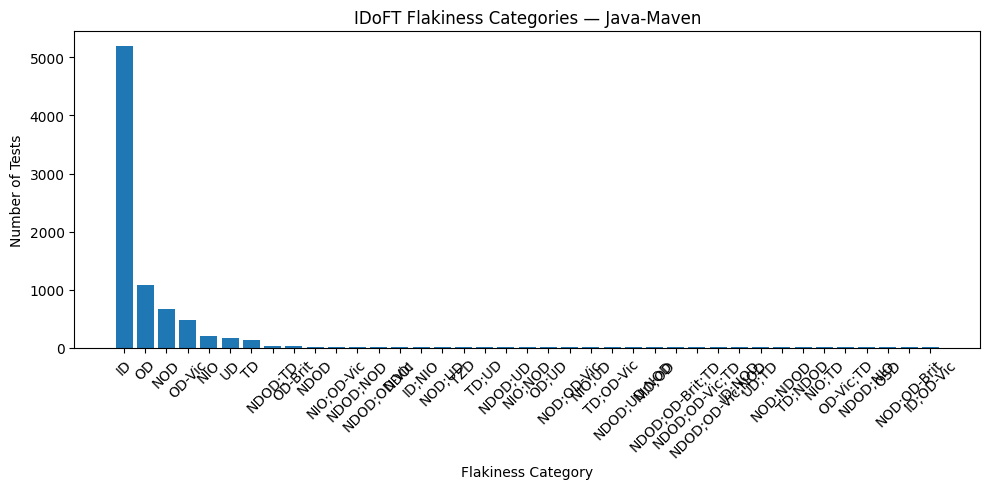

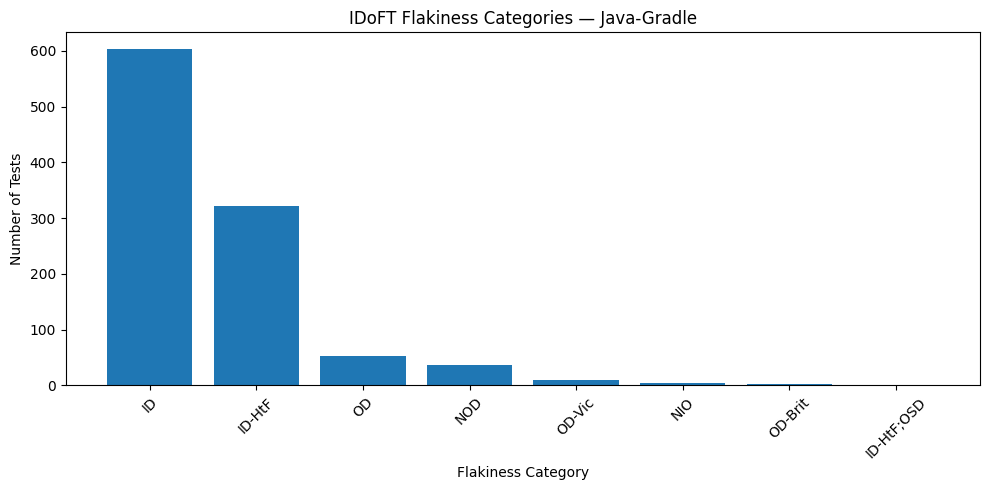

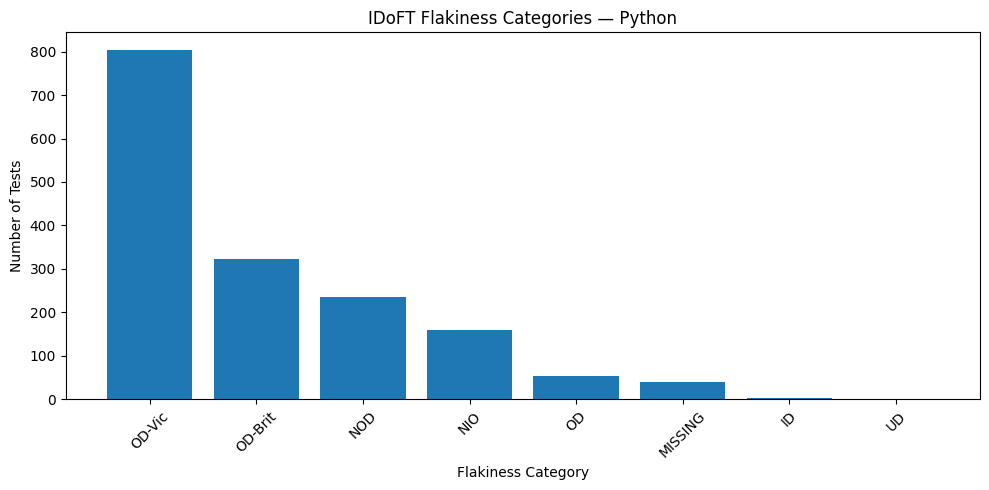

In [7]:
for dataset_name in category_df["Dataset"].unique():

    temp = (
        category_df[category_df["Dataset"] == dataset_name]
        .sort_values("Count", ascending=False)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(temp["Category"], temp["Count"])
    plt.xlabel("Flakiness Category")
    plt.ylabel("Number of Tests")
    plt.title(f"IDoFT Flakiness Categories — {dataset_name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Analyze IDoFT record statuses

In [8]:
status_results = []

for name, df in dfs.items():

    status_col = find_column(df, ["status"])

    if status_col is None:
        continue

    counts = (
        df[status_col]
        .fillna("MISSING")
        .astype(str)
        .str.strip()
        .value_counts()
    )

    for status, count in counts.items():
        status_results.append({
            "Dataset": name,
            "Status": status,
            "Count": count,
            "Percentage": round(100 * count / len(df), 2)
        })

status_df = pd.DataFrame(status_results)

display(
    status_df
    .sort_values(["Dataset", "Count"], ascending=[True, False])
)

,Dataset,Status,Count,Percentage
18,Java-Gradle,MISSING,510,49.56
19,Java-Gradle,Accepted,161,15.65
20,Java-Gradle,Opened,110,10.69
21,Java-Gradle,Unmaintained,77,7.48
22,Java-Gradle,RepoArchived,54,5.25
23,Java-Gradle,DeveloperWontFix,40,3.89
24,Java-Gradle,Deleted,31,3.01
25,Java-Gradle,RepoDeleted,18,1.75
26,Java-Gradle,Rejected,16,1.55
27,Java-Gradle,InspiredAFix,10,0.97


### Identify non-reproducible records

In [9]:
PROBLEM_KEYWORDS = [
    "irreproducible",
    "deleted",
    "archived",
    "unmaintained",
    "skipped",
    "unavailable",
    "invalid",
    "failed"
]

problem_records = []

for name, df in dfs.items():

    status_col = find_column(df, ["status"])

    if status_col is None:
        continue

    status_text = (
        df[status_col]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    mask = status_text.apply(
        lambda x: any(keyword in x for keyword in PROBLEM_KEYWORDS)
    )

    temp = df[mask].copy()

    if len(temp) > 0:
        temp.insert(0, "Dataset", name)
        problem_records.append(temp)

if problem_records:
    problem_df = pd.concat(problem_records, ignore_index=True)

    print(
        f"Found {len(problem_df)} records with potentially "
        "problematic/reproducibility-related statuses."
    )

    display(problem_df.head(20))
else:
    problem_df = pd.DataFrame()
    print("No problematic statuses detected.")

Found 2039 records with potentially problematic/reproducibility-related statuses.


,Dataset,Project URL,SHA Detected,Module Path,Fully-Qualified Test Name (packageName.ClassName.methodName),Category,Status,PR Link,Notes,Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod)
0,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeClai...,NIO;OD-Vic,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
1,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeClai...,OD-Brit,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
2,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeClai...,OD-Brit,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
3,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeClai...,OD-Brit,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
4,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeComp...,OD-Vic,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
5,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeComp...,NIO;OD-Vic,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
6,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeComp...,OD-Brit,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
7,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeDele...,OD-Vic,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
8,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeDele...,NIO;OD-Vic,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN
9,Java-Maven,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,activiti-spring-boot-starter,org.activiti.spring.boot.tasks.TaskRuntimeDele...,OD-Brit,Deleted,NaN,https://github.com/TestingResearchIllinois/fla...,NaN


### Dataset availability and record usability

In [10]:
availability_summary = []

for name, df in dfs.items():

    status_col = find_column(df, ["status"])

    if status_col is None:
        continue

    status_text = (
        df[status_col]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    problematic = status_text.apply(
        lambda x: any(k in x for k in PROBLEM_KEYWORDS)
    )

    availability_summary.append({
        "Dataset": name,
        "Total Records": len(df),
        "Potentially Problematic": int(problematic.sum()),
        "Potentially Usable": int((~problematic).sum()),
        "Problematic %": round(
            100 * problematic.mean(), 2
        )
    })

availability_df = pd.DataFrame(availability_summary)

display(availability_df)

,Dataset,Total Records,Potentially Problematic,Potentially Usable,Problematic %
0,Java-Maven,8075,995,7080,12.32
1,Java-Gradle,1029,180,849,17.49
2,Python,1618,864,754,53.40


### Measure project coverage across IDoFT datasets

In [11]:
project_summary = []

for name, df in dfs.items():

    project_col = find_column(
        df,
        ["project url", "project"]
    )

    if project_col is None:
        continue

    unique_projects = df[project_col].nunique()

    project_summary.append({
        "Dataset": name,
        "Tests": len(df),
        "Unique Projects": unique_projects,
        "Tests per Project": round(
            len(df) / unique_projects, 2
        )
    })

project_df = pd.DataFrame(project_summary)

display(project_df)

,Dataset,Tests,Unique Projects,Tests per Project
0,Java-Maven,8075,481,16.79
1,Java-Gradle,1029,96,10.72
2,Python,1618,343,4.72


### Identify projects with the highest numbers of flaky-test records

In [12]:
for name, df in dfs.items():

    project_col = find_column(
        df,
        ["project url", "project"]
    )

    if project_col is None:
        continue

    counts = (
        df[project_col]
        .value_counts()
        .head(20)
        .reset_index()
    )

    counts.columns = ["Project", "Flaky Test Records"]

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    display(counts)


Java-Maven


,Project,Flaky Test Records
0,https://github.com/alibaba/alibabacloud-tairje...,470
1,https://github.com/apache/hadoop,455
2,https://github.com/kiegroup/jbpm,361
3,https://github.com/apache/dubbo,339
4,https://github.com/apache/ignite-3,321
5,https://github.com/apache/nifi,190
6,https://github.com/wildfly/wildfly,157
7,https://github.com/alibaba/wasp,144
8,https://github.com/google/guava,140
9,https://github.com/pholser/junit-quickcheck,140



Java-Gradle


,Project,Flaky Test Records
0,https://github.com/java9-modularity/gradle-mod...,184
1,https://github.com/zhurlik/gradle-jboss-module...,73
2,https://github.com/micronaut-projects/micronau...,55
3,https://github.com/apache/ignite-3,54
4,https://github.com/marytts/gradle-marytts-voic...,52
5,https://github.com/spinnaker/clouddriver,46
6,https://github.com/GoogleContainerTools/jib,35
7,https://github.com/spring-projects/spring-auth...,34
8,https://github.com/aadnk/ProtocolLib,30
9,https://github.com/opensearch-project/OpenSearch,29



Python


,Project,Flaky Test Records
0,https://github.com/eth-cscs/reframe,137
1,https://github.com/santoshphilip/eppy,88
2,https://github.com/bennymeg/Butter.MAS.PythonAPI,53
3,https://github.com/tukiains/cloudnetpy,52
4,https://github.com/weka-io/easypy,44
5,https://github.com/guillaumewatteeux/centreon-...,41
6,https://github.com/thegetty/crom,38
7,https://github.com/huashengdun/webssh,29
8,https://github.com/dvc94ch/pykicad,28
9,https://github.com/max-k/flask-multi-redis,26


### Check tests appearing under multiple flaky categories

In [13]:
multi_category_results = []

for name, df in dfs.items():

    project_col = find_column(df, ["project url", "project"])
    test_col = find_column(
        df,
        ["fully-qualified test", "pytest test", "test name"]
    )
    category_col = find_column(df, ["category"])

    if not all([project_col, test_col, category_col]):
        continue

    grouped = (
        df.groupby([project_col, test_col])[category_col]
        .apply(
            lambda x: sorted(
                set(
                    str(v).strip()
                    for v in x.dropna()
                )
            )
        )
        .reset_index(name="Categories")
    )

    grouped["Number of Categories"] = (
        grouped["Categories"].apply(len)
    )

    multi = grouped[
        grouped["Number of Categories"] > 1
    ].copy()

    multi.insert(0, "Dataset", name)

    multi_category_results.append(multi)

if multi_category_results:

    multi_category_df = pd.concat(
        multi_category_results,
        ignore_index=True
    )

    print(
        "Tests associated with multiple flaky-test categories:"
    )

    display(multi_category_df.head(30))

else:
    multi_category_df = pd.DataFrame()
    print("No multiple-category tests found.")

Tests associated with multiple flaky-test categories:


,Dataset,Project URL,Fully-Qualified Test Name (packageName.ClassName.methodName),Categories,Number of Categories,Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod)
0,Java-Maven,https://github.com/apache/dubbo,org.apache.dubbo.config.ServiceConfigTest.test...,"[ID, NIO]",2,NaN
1,Java-Maven,https://github.com/apache/dubbo,org.apache.dubbo.config.spring.beans.factory.a...,"[ID, UD]",2,NaN
2,Java-Maven,https://github.com/apache/dubbo,org.apache.dubbo.config.spring.beans.factory.a...,"[ID, UD]",2,NaN
3,Java-Maven,https://github.com/apache/dubbo,org.apache.dubbo.config.spring.context.annotat...,"[ID, UD]",2,NaN
4,Java-Maven,https://github.com/apache/logging-log4j2,org.apache.logging.log4j.core.async.AsyncThrea...,"[NOD, OD]",2,NaN
5,Java-Maven,https://github.com/apache/servicecomb-java-cha...,org.apache.servicecomb.swagger.generator.core....,"[ID, OD]",2,NaN
6,Java-Maven,https://github.com/apache/servicecomb-java-cha...,org.apache.servicecomb.swagger.generator.core....,"[ID, OD]",2,NaN
7,Java-Maven,https://github.com/fluent/fluent-logger-java,org.fluentd.logger.TestFluentLogger.testInMult...,"[NDOD, TD]",2,NaN
8,Java-Maven,https://github.com/j256/ormlite-core,com.j256.ormlite.support.DatabaseConnectionPro...,"[ID, OD-Vic]",2,NaN
9,Java-Maven,https://github.com/j256/ormlite-core,com.j256.ormlite.support.DatabaseConnectionPro...,"[ID, OD-Vic]",2,NaN


### Check for duplicate IDoFT records

In [14]:
duplicate_summary = []

for name, df in dfs.items():

    project_col = find_column(
        df,
        ["project url", "project"]
    )

    test_col = find_column(
        df,
        ["fully-qualified test", "pytest test", "test name"]
    )

    sha_col = find_column(
        df,
        ["sha detected", "sha"]
    )

  
    if not all([project_col, test_col, sha_col]):
        print(f"Skipping {name}: required column not found.")
        print(
            f"Project={project_col}, "
            f"Test={test_col}, "
            f"SHA={sha_col}"
        )
        continue


    key_cols = [
        project_col,
        sha_col,
        test_col
    ]

    duplicated = df.duplicated(
        subset=key_cols,
        keep=False
    )

    duplicate_summary.append({
        "Dataset": name,
        "Total Records": len(df),
        "Duplicate-key Records": int(duplicated.sum()),
        "Duplicate %": round(
            100 * duplicated.mean(),
            2
        )
    })

duplicate_df = pd.DataFrame(
    duplicate_summary
)

display(duplicate_df)

,Dataset,Total Records,Duplicate-key Records,Duplicate %
0,Java-Maven,8075,22,0.27
1,Java-Gradle,1029,8,0.78
2,Python,1618,58,3.58


### Tests appearing at multiple commits

In [15]:
for name, df in dfs.items():

    project_col = find_column(df, ["project url", "project"])
    test_col = find_column(
        df,
        ["fully-qualified test", "pytest test", "test name"]
    )
    sha_col = find_column(
        df,
        ["sha detected", "sha"]
    )

    if not all([project_col, test_col, sha_col]):
        continue

    grouped = (
        df.groupby([project_col, test_col])[sha_col]
        .nunique()
        .reset_index(name="Number_of_SHAs")
    )

    repeated = grouped[
        grouped["Number_of_SHAs"] > 1
    ].sort_values(
        "Number_of_SHAs",
        ascending=False
    )

    print("\n", name)
    print(
        "Tests appearing at multiple detected commits:",
        len(repeated)
    )

    display(repeated.head(20))


 Java-Maven
Tests appearing at multiple detected commits: 68


,Project URL,Fully-Qualified Test Name (packageName.ClassName.methodName),Number_of_SHAs
7805,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7809,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7800,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
4023,https://github.com/apache/logging-log4j2,org.apache.logging.log4j.core.async.AsyncThrea...,3
7820,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7810,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7813,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7799,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7814,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3
7819,https://github.com/wildfly/wildfly,org.wildfly.dist.subsystem.xml.StandardConfigs...,3



 Java-Gradle
Tests appearing at multiple detected commits: 0


,Project URL,Fully-Qualified Test Name (packageName.ClassName.methodName),Number_of_SHAs



 Python
Tests appearing at multiple detected commits: 17


,Project URL,Pytest Test Name (PathToFile::TestClass::TestMethod or PathToFile::TestMethod),Number_of_SHAs
45,https://github.com/Gsllchb/DotDot,tests/test_dot.py::test_dot,2
46,https://github.com/Gsllchb/DotDot,tests/test_dotdot.py::test_dotdot,2
47,https://github.com/Gsllchb/DotDot,tests/test_dotdotdot.py::test_dotdotdot,2
48,https://github.com/Gsllchb/DotDot,tests/test_dotdotdotdot.py::test_dotdotdotdot,2
176,https://github.com/airbrake/pybrake,pybrake/test_celery_integration.py::test_celer...,2
277,https://github.com/chaosmail/python-fs,fs/tests/test_addpath.py::test_addpath,2
313,https://github.com/crazyscientist/osc-tiny,osctiny/tests/test_issues.py::TestIssue::test_get,2
345,https://github.com/den4uk/jsonextra,tests/test_jsonextra.py::test_disable_rex,2
616,https://github.com/goodmami/penman,tests/test_layout.py::test_rearrange,2
913,https://github.com/mehdisadeghi/clashogram,test_everything.py::MessageFactoryTestCase::te...,2


### Define criteria for selecting experimental candidates

In [16]:
JAVA_MAVEN = dfs.get("Java-Maven")

if JAVA_MAVEN is None:
    raise RuntimeError("Java-Maven IDoFT dataset not found.")

category_col = find_column(JAVA_MAVEN, ["category"])
status_col = find_column(JAVA_MAVEN, ["status"])
project_col = find_column(JAVA_MAVEN, ["project url", "project"])
sha_col = find_column(JAVA_MAVEN, ["sha detected", "sha"])
test_col = find_column(
    JAVA_MAVEN,
    ["fully-qualified test", "test name"]
)

print("Using columns:")
print("Project:", project_col)
print("SHA:", sha_col)
print("Test:", test_col)
print("Category:", category_col)
print("Status:", status_col)

candidate_categories = ["OD", "ID", "NIO", "NOD", "TD", "OSD"]

candidates = []

for category in candidate_categories:

    subset = JAVA_MAVEN[
        JAVA_MAVEN[category_col]
        .fillna("")
        .astype(str)
        .str.upper()
        .eq(category)
    ].copy()

    if len(subset) == 0:
        continue

   
    if status_col:
        good = ~subset[status_col].fillna("").astype(str).str.lower().apply(
            lambda x: any(k in x for k in PROBLEM_KEYWORDS)
        )

        preferred = subset[good]

        if len(preferred) > 0:
            subset = preferred

 
    row = subset.iloc[0]

    candidates.append({
        "Category": category,
        "Project": row[project_col],
        "SHA": row[sha_col],
        "Test": row[test_col],
        "Status": row[status_col] if status_col else ""
    })

candidate_df = pd.DataFrame(candidates)

display(candidate_df)

Using columns:
Project: Project URL
SHA: SHA Detected
Test: Fully-Qualified Test Name (packageName.ClassName.methodName)
Category: Category
Status: Status


,Category,Project,SHA,Test,Status
0,OD,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.able.TestBasicAble.test...,NaN
1,ID,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.annotation.IdTest.testCompos...,Opened
2,NIO,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,org.activiti.engine.test.cfg.RetryInterceptorT...,Accepted
3,NOD,https://github.com/Accenture/mercury,6b744cdbb2206feca62848df92b3bf542f890be5,org.platformlambda.automation.tests.WebSocketT...,DeveloperFixed
4,TD,https://github.com/Accenture/mercury,8586dc79f8bf75a929896f0aac03fe95824d9578,org.platformlambda.core.MulticastTest.routingTest,NaN
5,OSD,https://github.com/GoogleCloudPlatform/appengi...,d3160f0e47ca001d2c35b2b2d3b90bcb6438613b,com.google.cloud.tools.io.FilePermissionsTest....,NaN


In [18]:
OUTPUT_DIR = Path("/kaggle/working/flaky_test_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)


category_df.to_csv(
    OUTPUT_DIR / "category_analysis.csv",
    index=False
)

status_df.to_csv(
    OUTPUT_DIR / "status_analysis.csv",
    index=False
)

availability_df.to_csv(
    OUTPUT_DIR / "availability_analysis.csv",
    index=False
)

project_df.to_csv(
    OUTPUT_DIR / "project_analysis.csv",
    index=False
)

candidate_df.to_csv(
    OUTPUT_DIR / "experimental_candidates.csv",
    index=False
)

observations_df.to_csv(
    OUTPUT_DIR / "observations.csv",
    index=False
)

if len(problem_df) > 0:
    problem_df.to_csv(
        OUTPUT_DIR / "problematic_records.csv",
        index=False
    )

if len(multi_category_df) > 0:
    multi_category_df.to_csv(
        OUTPUT_DIR / "multi_category_tests.csv",
        index=False
    )

print("Saved results to:")
print(OUTPUT_DIR)

for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)

Saved results to:
/kaggle/working/flaky_test_analysis
 - availability_analysis.csv
 - category_analysis.csv
 - experimental_candidates.csv
 - multi_category_tests.csv
 - observations.csv
 - problematic_records.csv
 - project_analysis.csv
 - status_analysis.csv


### Install and verify Java and Maven prerequisites

In [20]:
import subprocess
import shutil
import os

def run_command(cmd):
    print(f"\n$ {cmd}")

    result = subprocess.run(
        cmd,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout)
    return result.returncode, result.stdout


print("=" * 70)
print("JAVA")
print("=" * 70)

run_command("java -version")

print("\n" + "=" * 70)
print("CHECKING MAVEN")
print("=" * 70)

maven_path = shutil.which("mvn")

if maven_path:
    print("Maven already installed:", maven_path)
else:
    print("Maven not found. Installing Maven...")


if not maven_path:

    result = subprocess.run(
        [
            "apt-get",
            "update",
            "-qq"
        ],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout[-3000:])

    result = subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "maven"
        ],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout[-5000:])

print("\n" + "=" * 70)
print("MAVEN VERSION")
print("=" * 70)

return_code, output = run_command("mvn -version")


print("\n" + "=" * 70)
print("GIT")
print("=" * 70)

run_command("git --version")


print("\n" + "=" * 70)
print("ENVIRONMENT SUMMARY")
print("=" * 70)

print("Java:", shutil.which("java"))
print("Maven:", shutil.which("mvn"))
print("Git:", shutil.which("git"))

if shutil.which("mvn"):
    print("\n✓ Java + Maven + Git are available.")
    print("You can proceed to the project experiments.")
else:
    print("\n✗ Maven installation failed.")
    print("Do not proceed to NonDex/iDFlakies yet.")

JAVA

$ java -version
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


CHECKING MAVEN
Maven not found. Installing Maven...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

-java_1.8-1_all.deb ...
Unpacking libjansi-native-java (1.8-1) ...
Selecting previously unselected package libjansi-java.
Preparing to unpack .../15-libjansi-java_1.18-1_all.deb ...
Unpacking libjansi-java (1.18-1) ...
Selecting previously unselected package libmaven-parent-java.
Preparing to unpack .../16-libmaven-parent-java_31-2_all.deb ...
Unpacking libmaven-parent-java (31-2) ...
Selecting previously unselected package libplexus-utils2-java.
Preparing to unpack .../17-libplexus-utils2-java_3.3.0-1_all.deb ...
Unpacking libplexus-utils2-java (3.

In [21]:
import subprocess

commands = [
    "java -version",
    "mvn -version",
    "git --version"
]

for cmd in commands:

    print("\n" + "=" * 70)
    print(cmd)
    print("=" * 70)

    result = subprocess.run(
        cmd,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout)


java -version
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


mvn -version
Apache Maven 3.6.3
Maven home: /usr/share/maven
Java version: 17.0.18, vendor: Ubuntu, runtime: /usr/lib/jvm/java-17-openjdk-amd64
Default locale: en_US, platform encoding: UTF-8
OS name: "linux", version: "6.12.90+", arch: "amd64", family: "unix"


git --version
git version 2.34.1



### Inspect the selected experimental candidates

In [22]:
print("Experimental candidates selected from IDoFT:")
print("=" * 80)

display(candidate_df)

Experimental candidates selected from IDoFT:


,Category,Project,SHA,Test,Status
0,OD,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.able.TestBasicAble.test...,NaN
1,ID,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.annotation.IdTest.testCompos...,Opened
2,NIO,https://github.com/Activiti/Activiti,b11f757a48600e53aaf3fcb7a3ba1ece6c463cb4,org.activiti.engine.test.cfg.RetryInterceptorT...,Accepted
3,NOD,https://github.com/Accenture/mercury,6b744cdbb2206feca62848df92b3bf542f890be5,org.platformlambda.automation.tests.WebSocketT...,DeveloperFixed
4,TD,https://github.com/Accenture/mercury,8586dc79f8bf75a929896f0aac03fe95824d9578,org.platformlambda.core.MulticastTest.routingTest,NaN
5,OSD,https://github.com/GoogleCloudPlatform/appengi...,d3160f0e47ca001d2c35b2b2d3b90bcb6438613b,com.google.cloud.tools.io.FilePermissionsTest....,NaN


### Display Java-Maven records for the selected categories

In [23]:
java_df = dfs["Java-Maven"]

category_col = find_column(java_df, ["category"])
status_col = find_column(java_df, ["status"])
project_col = find_column(java_df, ["project url", "project"])
sha_col = find_column(java_df, ["sha detected", "sha"])
test_col = find_column(
    java_df,
    ["fully-qualified test", "test name"]
)

interesting_categories = ["OD", "ID", "NIO", "NOD", "TD"]

candidate_records = java_df[
    java_df[category_col]
    .fillna("")
    .astype(str)
    .str.upper()
    .isin(interesting_categories)
].copy()

columns_to_show = [
    c for c in [
        project_col,
        sha_col,
        test_col,
        category_col,
        status_col
    ]
    if c is not None
]

print("\nAvailable records:")
display(
    candidate_records[columns_to_show]
    .head(30)
)


Available records:


,Project URL,SHA Detected,Fully-Qualified Test Name (packageName.ClassName.methodName),Category,Status
0,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.annotation.IdTest.testCompos...,ID,Opened
1,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.ComplexEntityTe...,ID,Opened
2,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.FieldHelperTest...,ID,Opened
3,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.FieldHelperTest...,ID,Opened
4,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.SqlHelperTest.t...,ID,Opened
5,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.able.TestBasicAble.test...,OD,NaN
6,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
7,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
8,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
9,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted


### Check whether the candidate repository is accessible

In [24]:
import requests
import pandas as pd

def normalize_github_url(url):
    if pd.isna(url):
        return None

    url = str(url).strip()

    if url.endswith(".git"):
        url = url[:-4]

    return url.rstrip("/")


repo_check = []

for _, row in candidate_records.head(30).iterrows():

    url = normalize_github_url(row[project_col])

    if not url:
        continue

    try:
        response = requests.get(
            url,
            timeout=10,
            allow_redirects=True
        )

        accessible = response.status_code == 200

        repo_check.append({
            "Project": url,
            "HTTP_Status": response.status_code,
            "Accessible": accessible
        })

    except Exception as e:

        repo_check.append({
            "Project": url,
            "HTTP_Status": None,
            "Accessible": False,
            "Error": str(e)
        })

repo_check_df = pd.DataFrame(repo_check)

display(repo_check_df)

,Project,HTTP_Status,Accessible
0,https://github.com/abel533/Mapper,200,True
1,https://github.com/abel533/Mapper,200,True
2,https://github.com/abel533/Mapper,200,True
3,https://github.com/abel533/Mapper,200,True
4,https://github.com/abel533/Mapper,200,True
5,https://github.com/abel533/Mapper,200,True
6,https://github.com/abel533/Mapper,200,True
7,https://github.com/abel533/Mapper,200,True
8,https://github.com/abel533/Mapper,200,True
9,https://github.com/abel533/Mapper,200,True


In [25]:
candidate = candidate_df.iloc[0]

print("Project:", candidate["Project"])
print("SHA:", candidate["SHA"])
print("Test:", candidate["Test"])
print("Category:", candidate["Category"])

Project: https://github.com/abel533/Mapper
SHA: 3c0b3307011fad53f811e08d05147d94fc6c0d67
Test: tk.mybatis.mapper.test.able.TestBasicAble.testInsert
Category: OD


### Check out the exact IDoFT commit for the candidate

In [26]:
PROJECT_URL = str(candidate["Project"]).strip()
PROJECT_SHA = str(candidate["SHA"]).strip()

PROJECT_NAME = PROJECT_URL.rstrip("/").split("/")[-1]

if PROJECT_NAME.endswith(".git"):
    PROJECT_NAME = PROJECT_NAME[:-4]

PROJECT_DIR = (
    Path("/kaggle/working/projects") /
    PROJECT_NAME
)

PROJECT_DIR.parent.mkdir(
    parents=True,
    exist_ok=True
)

print("Project URL:", PROJECT_URL)
print("Project SHA:", PROJECT_SHA)
print("Local directory:", PROJECT_DIR)

if not PROJECT_DIR.exists():

    result = subprocess.run(
        [
            "git",
            "clone",
            PROJECT_URL,
            str(PROJECT_DIR)
        ],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    print(result.stdout)

    if result.returncode != 0:
        raise RuntimeError(
            "Git clone failed."
        )

else:

    print("Project already cloned.")

Project URL: https://github.com/abel533/Mapper
Project SHA: 3c0b3307011fad53f811e08d05147d94fc6c0d67
Local directory: /kaggle/working/projects/Mapper
Cloning into '/kaggle/working/projects/Mapper'...



### Inspect the preliminary candidate project structure

In [27]:
print("Fetching repository history...")

result = subprocess.run(
    ["git", "fetch", "--all", "--tags"],
    cwd=PROJECT_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(result.stdout[-5000:])


print("\nChecking out IDoFT SHA:", PROJECT_SHA)

result = subprocess.run(
    ["git", "checkout", PROJECT_SHA],
    cwd=PROJECT_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(result.stdout)

if result.returncode != 0:

    raise RuntimeError(
        f"Could not checkout SHA {PROJECT_SHA}"
    )



result = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=PROJECT_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

actual_sha = result.stdout.strip()

print("\nExpected SHA:")
print(PROJECT_SHA)

print("\nActual HEAD:")
print(actual_sha)

if actual_sha.startswith(PROJECT_SHA) or PROJECT_SHA.startswith(actual_sha):

    print("\n✓ Correct IDoFT commit checked out.")

else:

    print(
        "\n⚠ WARNING: Checked-out commit does not match "
        "the IDoFT SHA."
    )

Fetching repository history...
Fetching origin


Checking out IDoFT SHA: 3c0b3307011fad53f811e08d05147d94fc6c0d67
Note: switching to '3c0b3307011fad53f811e08d05147d94fc6c0d67'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 3c0b330 Update SqlCriteriaHelper.java


Expected SHA:
3c0b3307011fad53f811e08d05147d94fc6c0d67

Actual HEAD:
3c0b3307011fad53f811e08d05147d94fc6c0d67

✓ Correct IDoFT commit checked out.


In [28]:
print("Project files:")
print("=" * 80)

for path in sorted(PROJECT_DIR.iterdir()):

    print(path.name)

Project files:
.git
.gitignore
.gitmodules
.travis.yml
LICENSE
README.md
all
base
core
extra
generator
pom.xml
spring
spring-boot-starter
weekend
wiki


In [29]:
print("\nBuild files:")

for filename in [
    "pom.xml",
    "build.gradle",
    "build.gradle.kts",
    "settings.gradle",
    "settings.gradle.kts"
]:

    path = PROJECT_DIR / filename

    print(
        f"{filename}:",
        "FOUND" if path.exists() else "not found"
    )


Build files:
pom.xml: FOUND
build.gradle: not found
build.gradle.kts: not found
settings.gradle: not found
settings.gradle.kts: not found


In [30]:
pom_path = PROJECT_DIR / "pom.xml"

if pom_path.exists():

    pom_text = pom_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    print(
        pom_text[:20000]
    )

else:

    print(
        "No pom.xml found."
    )

<!--
  ~ The MIT License (MIT)
  ~
  ~ Copyright (c) 2018 abel533@gmail.com
  ~
  ~ Permission is hereby granted, free of charge, to any person obtaining a copy
  ~ of this software and associated documentation files (the "Software"), to deal
  ~ in the Software without restriction, including without limitation the rights
  ~ to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
  ~ copies of the Software, and to permit persons to whom the Software is
  ~ furnished to do so, subject to the following conditions:
  ~
  ~ The above copyright notice and this permission notice shall be included in
  ~ all copies or substantial portions of the Software.
  ~
  ~ THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
  ~ IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
  ~ FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
  ~ AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
  ~ LIABI

### Find the source of the Java compiler version setting

In [31]:
import subprocess
import time

print("=" * 80)
print("RUNNING BASELINE: mvn test")
print("=" * 80)

start_time = time.time()

result = subprocess.run(
    ["mvn", "test"],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

elapsed = time.time() - start_time

print(result.stdout)

print("\n" + "=" * 80)
print("BASELINE RESULT")
print("=" * 80)

print("Return code:", result.returncode)
print(f"Elapsed time: {elapsed:.2f} seconds")

if result.returncode == 0:
    print("STATUS: BUILD/TEST PASSED")
else:
    print("STATUS: BUILD/TEST FAILED")

RUNNING BASELINE: mvn test
[INFO] Scanning for projects...
Progress (1): 4.1 kB
Progress (1): 8.2 kB
Progress (1): 9.1 kB
                    
Downloaded from central: https://repo.maven.apache.org/maven2/tk/mybatis/mapper-parent/3/mapper-parent-3.pom (9.1 kB at 15 kB/s)
Progress (1): 4.1 kB
Progress (1): 8.2 kB
Progress (1): 12 kB 
Progress (1): 16 kB
Progress (1): 20 kB
Progress (1): 25 kB
Progress (1): 29 kB
Progress (1): 33 kB
Progress (1): 37 kB
Progress (1): 41 kB
Progress (1): 45 kB
Progress (1): 49 kB
Progress (1): 53 kB
Progress (1): 57 kB
Progress (1): 61 kB
Progress (1): 66 kB
Progress (1): 70 kB
Progress (1): 74 kB
Progress (1): 78 kB
Progress (1): 82 kB
Progress (1): 86 kB
Progress (1): 90 kB
Progress (1): 94 kB
Progress (1): 98 kB
Progress (1): 102 kB
Progress (1): 106 kB
Progress (1): 111 kB
Progress (1): 115 kB
Progress (1): 119 kB
Progress (1): 123 kB
Progress (1): 127 kB
Progress (1): 131 kB
Progress (1): 135 kB
Progress (1): 139 kB
Progress (1): 142 kB
              

### Determine inherited Maven Java configuration

In [32]:
import subprocess

print("=" * 80)
print("EFFECTIVE MAVEN CONFIGURATION")
print("=" * 80)

result = subprocess.run(
    ["mvn", "help:effective-pom", "-Doutput=effective-pom.xml"],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[-5000:])

effective_pom = PROJECT_DIR / "effective-pom.xml"

if effective_pom.exists():
    text = effective_pom.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    print("\n" + "=" * 80)
    print("JAVA / COMPILER SETTINGS FOUND IN EFFECTIVE POM")
    print("=" * 80)

    lines = text.splitlines()

    keywords = [
        "<source>",
        "<target>",
        "<maven.compiler.source>",
        "<maven.compiler.target>",
        "<artifactId>maven-compiler-plugin",
        "<version>"
    ]

    for i, line in enumerate(lines):
        if any(keyword in line for keyword in keywords):
            start = max(0, i - 3)
            end = min(len(lines), i + 4)

            print("\n".join(lines[start:end]))
            print("-" * 60)

else:
    print("\nCould not generate effective-pom.xml")

EFFECTIVE MAVEN CONFIGURATION
 | 328 kB | 367/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 371/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 375/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 379/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 383/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 387/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 392/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 396/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 400/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 404/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 408/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 412/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 416/647 kB | 7.2 kB
Progress (4): 473 kB | 328 kB | 420/647 kB | 7.2 kB
                                                   
Downloaded from central: https://repo.maven.apache.org/maven2/org/jsoup/jsoup/1.19.1/jsoup-1.19.1.jar (473 kB at 1.5 MB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/jdom/jdom2/2.0.6.1/jd

In [33]:
from pathlib import Path

patterns = [
    "maven.compiler.source",
    "maven.compiler.target",
    "<source>1.6</source>",
    "<target>1.6</target>",
    "<source>6</source>",
    "<target>6</target>",
    "maven-compiler-plugin",
    "<java.version>",
    "<javaVersion>"
]

pom_files = list(PROJECT_DIR.rglob("pom.xml"))

print("=" * 80)
print("SEARCHING PROJECT POM FILES")
print("=" * 80)
print(f"Total POM files: {len(pom_files)}")

found = []

for pom in pom_files:

    try:
        lines = pom.read_text(
            encoding="utf-8",
            errors="ignore"
        ).splitlines()
    except Exception:
        continue

    for i, line in enumerate(lines):

        if any(p.lower() in line.lower() for p in patterns):

            found.append({
                "file": str(pom.relative_to(PROJECT_DIR)),
                "line": i + 1,
                "text": line.strip()
            })

print("\n" + "=" * 80)
print("MATCHES")
print("=" * 80)

if found:

    for item in found:
        print(
            f"{item['file']}:{item['line']} -> "
            f"{item['text']}"
        )

else:
    print("No explicit Java/compiler configuration found.")

SEARCHING PROJECT POM FILES
Total POM files: 16

MATCHES
No explicit Java/compiler configuration found.


In [34]:
import subprocess
from pathlib import Path

print("=" * 80)
print("RESOLVING tk.mybatis:mapper-parent:3")
print("=" * 80)

result = subprocess.run(
    [
        "mvn",
        "help:effective-pom",
        "-Doutput=parent-effective-pom.xml"
    ],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("Maven return code:", result.returncode)


parent_effective = PROJECT_DIR / "parent-effective-pom.xml"

if parent_effective.exists():

    text = parent_effective.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    lines = text.splitlines()

    print("\n" + "=" * 80)
    print("COMPILER CONFIGURATION")
    print("=" * 80)

    found = False

    for i, line in enumerate(lines):

        if (
            "maven-compiler-plugin" in line
            or "<source>" in line
            or "<target>" in line
            or "maven.compiler.source" in line
            or "maven.compiler.target" in line
        ):

            found = True

            start = max(0, i - 4)
            end = min(len(lines), i + 5)

            print(
                "\n".join(
                    f"{j+1}: {lines[j]}"
                    for j in range(start, end)
                )
            )

            print("-" * 60)

    if not found:
        print("No compiler configuration found.")

else:

    print("Could not generate effective POM.")

RESOLVING tk.mybatis:mapper-parent:3
Maven return code: 0

COMPILER CONFIGURATION
186:         </plugins>
187:       </pluginManagement>
188:       <plugins>
189:         <plugin>
190:           <artifactId>maven-compiler-plugin</artifactId>
191:           <version>3.16.0</version>
192:           <configuration>
193:             <source>1.6</source>
194:             <target>1.6</target>
------------------------------------------------------------
189:         <plugin>
190:           <artifactId>maven-compiler-plugin</artifactId>
191:           <version>3.16.0</version>
192:           <configuration>
193:             <source>1.6</source>
194:             <target>1.6</target>
195:           </configuration>
196:         </plugin>
197:         <plugin>
------------------------------------------------------------
190:           <artifactId>maven-compiler-plugin</artifactId>
191:           <version>3.16.0</version>
192:           <configuration>
193:             <source>1.6</source>
194:   

In [35]:
import subprocess

print("=" * 80)
print("AVAILABLE JAVA INSTALLATIONS")
print("=" * 80)

result = subprocess.run(
    ["bash", "-c", "ls -la /usr/lib/jvm/"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

print("\n" + "=" * 80)
print("JAVA COMMANDS")
print("=" * 80)

for cmd in ["java", "javac", "java8", "javac8"]:
    result = subprocess.run(
        ["bash", "-c", f"command -v {cmd} || true"],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    print(f"{cmd}: {result.stdout.strip() or 'not found'}")

AVAILABLE JAVA INSTALLATIONS
total 20
drwxr-xr-x 3 root root 4096 May 12 13:11 .
drwxr-xr-x 1 root root 4096 May 12 13:11 ..
lrwxrwxrwx 1 root root   21 Jan 29  2026 java-1.17.0-openjdk-amd64 -> java-17-openjdk-amd64
-rw-r--r-- 1 root root 1773 Jan 29  2026 .java-1.17.0-openjdk-amd64.jinfo
drwxr-xr-x 9 root root 4096 May 12 13:11 java-17-openjdk-amd64


JAVA COMMANDS
java: /usr/bin/java
javac: /usr/bin/javac
java8: not found
javac8: not found


In [36]:
import subprocess
import time

print("=" * 80)
print("CONTROLLED COMPATIBILITY TEST")
print("Overriding Java source/target to 8 WITHOUT modifying pom.xml")
print("=" * 80)

start_time = time.time()

result = subprocess.run(
    [
        "mvn",
        "test",
        "-Dmaven.compiler.source=8",
        "-Dmaven.compiler.target=8"
    ],
    cwd=PROJECT_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

elapsed = time.time() - start_time

output = result.stdout

print(output[-12000:])

print("\n" + "=" * 80)
print("RESULT")
print("=" * 80)

print("Return code:", result.returncode)
print(f"Elapsed time: {elapsed:.2f} seconds")

if result.returncode == 0:
    print("STATUS: BUILD/TEST PASSED")
else:
    print("STATUS: BUILD/TEST FAILED")

CONTROLLED COMPATIBILITY TEST
Overriding Java source/target to 8 WITHOUT modifying pom.xml
ven-compiler-plugin is missing. @ tk.mybatis:mapper-parent:3, /root/.m2/repository/tk/mybatis/mapper-parent/3/mapper-parent-3.pom, line 141, column 21
[WARNING] 'build.plugins.plugin.version' for org.apache.maven.plugins:maven-source-plugin is missing. @ tk.mybatis:mapper-parent:3, /root/.m2/repository/tk/mybatis/mapper-parent/3/mapper-parent-3.pom, line 149, column 21
[WARNING] 
[WARNING] Some problems were encountered while building the effective model for tk.mybatis:mapper-generator:jar:1.1.5
[WARNING] 'build.plugins.plugin.version' for org.apache.maven.plugins:maven-compiler-plugin is missing. @ tk.mybatis:mapper-parent:3, /root/.m2/repository/tk/mybatis/mapper-parent/3/mapper-parent-3.pom, line 141, column 21
[WARNING] 'build.plugins.plugin.version' for org.apache.maven.plugins:maven-source-plugin is missing. @ tk.mybatis:mapper-parent:3, /root/.m2/repository/tk/mybatis/mapper-parent/3/mappe

### Create a compact flaky-category summary

In [37]:
java_df = dfs["Java-Maven"].copy()

category_col = find_column(java_df, ["category"])
status_col = find_column(java_df, ["status"])
project_col = find_column(java_df, ["project url", "project"])
sha_col = find_column(java_df, ["sha detected", "sha"])
test_col = find_column(java_df, ["fully-qualified test", "test name"])

print("=" * 80)
print("JAVA-MAVEN CANDIDATES")
print("=" * 80)


wanted_categories = ["OD", "ID", "NIO", "NOD", "TD"]

candidate_pool = java_df[
    java_df[category_col]
    .fillna("")
    .astype(str)
    .str.upper()
    .isin(wanted_categories)
].copy()


bad_status_words = [
    "deleted",
    "archived",
    "unmaintained",
    "irreproducible"
]

def looks_problematic(status):
    s = str(status).lower()
    return any(word in s for word in bad_status_words)

candidate_pool = candidate_pool[
    ~candidate_pool[status_col].apply(looks_problematic)
].copy()


display_cols = [
    c for c in [
        project_col,
        sha_col,
        test_col,
        category_col,
        status_col
    ]
    if c is not None
]

print(f"\nCandidate count: {len(candidate_pool)}")

display(
    candidate_pool[display_cols]
    .drop_duplicates()
    .head(50)
)

JAVA-MAVEN CANDIDATES

Candidate count: 6421


,Project URL,SHA Detected,Fully-Qualified Test Name (packageName.ClassName.methodName),Category,Status
0,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.annotation.IdTest.testCompos...,ID,Opened
1,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.ComplexEntityTe...,ID,Opened
2,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.FieldHelperTest...,ID,Opened
3,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.FieldHelperTest...,ID,Opened
4,https://github.com/abel533/Mapper,1764748eedb2f320a0d1c43cb4f928c4ccb1f2f5,tk.mybatis.mapper.mapperhelper.SqlHelperTest.t...,ID,Opened
5,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.able.TestBasicAble.test...,OD,NaN
6,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
7,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
8,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted
9,https://github.com/abel533/Mapper,3c0b3307011fad53f811e08d05147d94fc6c0d67,tk.mybatis.mapper.test.country.TestDeleteByPri...,OD,Accepted


### Identify projects with many candidate records

In [38]:
import pandas as pd

df = dfs["Java-Maven"].copy()

category_col = find_column(df, ["category"])
status_col   = find_column(df, ["status"])
project_col  = find_column(df, ["project url", "project"])
sha_col      = find_column(df, ["sha detected", "sha"])
test_col     = find_column(df, ["fully-qualified test", "test name"])


df["_category"] = df[category_col].fillna("").astype(str).str.upper()
df["_status"]   = df[status_col].fillna("").astype(str)
df["_project"]  = df[project_col].fillna("").astype(str)
df["_sha"]      = df[sha_col].fillna("").astype(str)
df["_test"]     = df[test_col].fillna("").astype(str)


bad_words = [
    "deleted",
    "archived",
    "unmaintained",
    "irreproducible"
]

mask_bad = df["_status"].str.lower().apply(
    lambda x: any(w in x for w in bad_words)
)

usable = df[~mask_bad].copy()

print("=" * 80)
print("IDoFT JAVA-MAVEN CANDIDATE SUMMARY")
print("=" * 80)

print(f"Total records:          {len(df)}")
print(f"After status filtering: {len(usable)}")

print("\nRecords by category:")
display(
    usable["_category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Records")
)

print("\nUnique projects by category:")
display(
    usable.groupby("_category")["_project"]
    .nunique()
    .sort_values(ascending=False)
    .rename("Unique Projects")
    .reset_index()
)

IDoFT JAVA-MAVEN CANDIDATE SUMMARY
Total records:          8075
After status filtering: 7094

Records by category:


,Category,Records
0,ID,4668
1,OD,947
2,NOD,526
3,OD-VIC,443
4,NIO,180
5,TD,100
6,UD,92
7,NDOD;TD,31
8,OD-BRIT,18
9,NDOD,12



Unique projects by category:


,_category,Unique Projects
0,ID,367
1,OD,51
2,NOD,34
3,OD-VIC,32
4,UD,20
5,TD,19
6,NIO,15
7,OD-BRIT,12
8,NDOD,8
9,NDOD;NOD,6


### Extract the exact IDoFT record for the selected candidate

In [39]:
import pandas as pd

df = dfs["Java-Maven"].copy()

category_col = find_column(df, ["category"])
status_col   = find_column(df, ["status"])
project_col  = find_column(df, ["project url", "project"])
sha_col      = find_column(df, ["sha detected", "sha"])
test_col     = find_column(df, ["fully-qualified test", "test name"])


df["_category"] = df[category_col].fillna("").astype(str).str.upper()
df["_project"]  = df[project_col].fillna("").astype(str)
df["_sha"]      = df[sha_col].fillna("").astype(str)
df["_test"]     = df[test_col].fillna("").astype(str)


bad_words = [
    "deleted",
    "archived",
    "unmaintained",
    "irreproducible"
]

df["_bad_status"] = (
    df[status_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .apply(lambda x: any(w in x for w in bad_words))
)

df = df[~df["_bad_status"]].copy()

wanted = ["OD", "ID", "NIO", "NOD", "TD"]

summary = []

for category in wanted:

    x = df[df["_category"] == category]

    summary.append({
        "Category": category,
        "Records": len(x),
        "Unique Projects": x["_project"].nunique(),
        "Unique Tests": x["_test"].nunique(),
        "Unique SHAs": x["_sha"].nunique()
    })

summary_df = pd.DataFrame(summary)

print("=" * 80)
print("COMPACT IDoFT CATEGORY SUMMARY")
print("=" * 80)

display(summary_df)

COMPACT IDoFT CATEGORY SUMMARY


,Category,Records,Unique Projects,Unique Tests,Unique SHAs
0,OD,947,51,947,59
1,ID,4668,367,4599,603
2,NIO,180,15,180,16
3,NOD,526,34,525,41
4,TD,100,19,100,20


### Find clean accepted NiFi candidates for NonDex

In [40]:
for category in ["OD", "ID", "NIO", "NOD", "TD"]:

    x = df[df["_category"] == category].copy()

    if len(x) == 0:
        print(f"\n{category}: NO RECORDS")
        continue

    project_counts = (
        x.groupby("_project")
        .agg(
            Tests=("_test", "nunique"),
            SHAs=("_sha", "nunique"),
            Records=("_test", "size")
        )
        .sort_values(
            ["Tests", "SHAs", "Records"],
            ascending=False
        )
        .head(5)
    )

    print("\n" + "=" * 80)
    print(f"TOP {category} PROJECTS")
    print("=" * 80)

    display(project_counts)


TOP OD PROJECTS


,Tests,SHAs,Records
_project,,,
https://github.com/apache/hadoop,363,2,363
https://github.com/alibaba/alibabacloud-tairjedis-sdk,134,1,134
https://github.com/Thomas-S-B/visualee,47,1,47
https://github.com/apache/ozone,43,1,43
https://github.com/apache/nifi,35,2,35



TOP ID PROJECTS


,Tests,SHAs,Records
_project,,,
https://github.com/kiegroup/jbpm,361,1,361
https://github.com/apache/dubbo,159,7,160
https://github.com/apache/nifi,146,5,148
https://github.com/google/guava,139,2,140
https://github.com/apache/flink,130,10,134



TOP NIO PROJECTS


,Tests,SHAs,Records
_project,,,
https://github.com/pholser/junit-quickcheck,120,1,120
https://github.com/apache/dubbo,12,1,12
https://github.com/apache/hbase,12,1,12
https://github.com/apache/hadoop,9,1,9
https://github.com/spring-projects/spring-boot,8,1,8



TOP NOD PROJECTS


,Tests,SHAs,Records
_project,,,
https://github.com/alibaba/alibabacloud-tairjedis-sdk,336,1,336
https://github.com/apache/gora,35,1,35
https://github.com/biojava/biojava,27,1,27
https://github.com/apache/hadoop,26,2,26
https://github.com/apache/pulsar,20,1,20



TOP TD PROJECTS


,Tests,SHAs,Records
_project,,,
https://github.com/TooTallNate/Java-WebSocket,22,1,22
https://github.com/Alluxio/alluxio,17,1,17
https://github.com/Activiti/Activiti,13,1,13
https://github.com/apache/httpcore,11,1,11
https://github.com/apache/dubbo,9,1,9


### Extract the exact accepted NiFi ID-category record

In [41]:
selected_projects = {
    "HADOOP": "https://github.com/apache/hadoop",
    "GUAVA": "https://github.com/google/guava",
    "NIFI": "https://github.com/apache/nifi"
}

selected_categories = ["OD", "ID"]

for project_name, project_url in selected_projects.items():

    print("\n" + "=" * 90)
    print(f"{project_name}")
    print("=" * 90)

    x = df[
        (df["_project"].str.rstrip("/") == project_url.rstrip("/")) &
        (df["_category"].isin(selected_categories))
    ].copy()

    if len(x) == 0:
        print("No matching records.")
        continue

    cols = [
        "_category",
        "_sha",
        "_test",
        status_col
    ]

    x = x[cols].drop_duplicates()

    print(f"Number of records: {len(x)}")

    display(x.head(10))


HADOOP
Number of records: 377


,_category,_sha,_test,Status
1993,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.crypto.key.kms.server.TestKM...,NaN
1994,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.crypto.key.kms.server.TestKM...,NaN
1995,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.fs.http.server.TestHttpFSAcc...,NaN
1996,OD,cc2babc1f75c93bf89a8f10da525f944c15d02ea,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
1997,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
1999,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
2000,OD,cc2babc1f75c93bf89a8f10da525f944c15d02ea,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
2002,OD,cc2babc1f75c93bf89a8f10da525f944c15d02ea,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
2003,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN
2004,OD,cc2babc1f75c93bf89a8f10da525f944c15d02ea,org.apache.hadoop.fs.http.server.TestHttpFSSer...,NaN



GUAVA
Number of records: 140


,_category,_sha,_test,Status
4711,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.FilteredCollectionsT...,MovedOrRenamed
4712,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.FilteredCollectionsT...,MovedOrRenamed
4713,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.ForwardingMapTest.te...,MovedOrRenamed
4714,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.ImmutableMultimapAsM...,MovedOrRenamed
4715,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.MapsTest.testToStrin...,MovedOrRenamed
4716,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.MapsTest.testToStrin...,MovedOrRenamed
4717,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.MultimapsTest.testUn...,MovedOrRenamed
4718,ID,688b9c2cfae305f38c601efd4a7a9e9549db9b1f,com.google.common.collect.MultimapsTest.testUn...,NaN
4719,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.MultimapsTest.testUn...,MovedOrRenamed
4720,ID,a197d99b96d69ea75a2c4a15ecd8a730dd3270d6,com.google.common.collect.MultimapsTest.testUn...,MovedOrRenamed



NIFI
Number of records: 183


,_category,_sha,_test,Status
3305,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3306,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3307,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.coordination.http.repl...,Accepted
3308,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.coordination.http.Stan...,NaN
3309,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.manager.BulletinMerger...,Accepted
3310,OD,41ff6f076b2e5346cf695ff2064e5dcfe249c124,org.apache.nifi.controller.state.providers.zoo...,MovedOrRenamed
3311,OD,41ff6f076b2e5346cf695ff2064e5dcfe249c124,org.apache.nifi.controller.state.providers.zoo...,MovedOrRenamed
3312,OD,41ff6f076b2e5346cf695ff2064e5dcfe249c124,org.apache.nifi.controller.state.providers.zoo...,MovedOrRenamed
3313,OD,41ff6f076b2e5346cf695ff2064e5dcfe249c124,org.apache.nifi.controller.state.providers.zoo...,MovedOrRenamed
3314,OD,41ff6f076b2e5346cf695ff2064e5dcfe249c124,org.apache.nifi.controller.state.providers.zoo...,MovedOrRenamed


### Extract the exact Hadoop order-dependent candidate record

In [42]:
nifi = df[
    df["_project"].str.rstrip("/") ==
    "https://github.com/apache/nifi"
].copy()


nifi = nifi[
    nifi["_category"].isin(["OD", "ID"])
].copy()


nifi_accepted = nifi[
    nifi[status_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .eq("accepted")
].copy()

print("=" * 90)
print("NIFI ACCEPTED CANDIDATES")
print("=" * 90)

for category in ["OD", "ID"]:

    x = nifi_accepted[
        nifi_accepted["_category"] == category
    ].drop_duplicates(
        subset=["_category", "_sha", "_test"]
    )

    print(f"\n{category}: {len(x)} accepted records")

    display(
        x[
            ["_category", "_sha", "_test", status_col]
        ].head(10)
    )

NIFI ACCEPTED CANDIDATES

OD: 0 accepted records


,_category,_sha,_test,Status



ID: 45 accepted records


,_category,_sha,_test,Status
3305,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3306,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3307,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.coordination.http.repl...,Accepted
3309,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.manager.BulletinMerger...,Accepted
3332,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.distributed.cache.server.map.D...,Accepted
3333,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3334,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3335,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3336,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3337,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted


### Print the exact selected test names and commit SHAs

In [43]:
nifi_id = nifi_accepted[
    nifi_accepted["_category"] == "ID"
].copy()

nifi_id = nifi_id[
    ["_category", "_sha", "_test", status_col]
].drop_duplicates()

print("=" * 90)
print("ACCEPTED NIFI ID CANDIDATES")
print("=" * 90)

display(nifi_id.head(10))

ACCEPTED NIFI ID CANDIDATES


,_category,_sha,_test,Status
3305,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3306,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.authorization.CompositeUserGro...,Accepted
3307,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.coordination.http.repl...,Accepted
3309,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.cluster.manager.BulletinMerger...,Accepted
3332,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.distributed.cache.server.map.D...,Accepted
3333,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3334,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3335,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3336,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted
3337,ID,2bd752d868a8f3e36113b078bb576cf054e945e8,org.apache.nifi.hbase.TestFetchHBaseRow.testFe...,Accepted


### Clone Hadoop and check out the exact IDoFT commit

In [44]:
hadoop = df[
    df["_project"].str.rstrip("/") ==
    "https://github.com/apache/hadoop"
].copy()

hadoop_od = hadoop[
    hadoop["_category"] == "OD"
].copy()


preferred_statuses = [
    "Accepted",
    "accepted"
]

hadoop_od["_status_priority"] = (
    hadoop_od[status_col]
    .fillna("")
    .astype(str)
    .isin(preferred_statuses)
    .astype(int)
)

hadoop_od = hadoop_od.sort_values(
    "_status_priority",
    ascending=False
)

hadoop_od = hadoop_od[
    ["_category", "_sha", "_test", status_col]
].drop_duplicates()

print("=" * 90)
print("HADOOP OD CANDIDATES")
print("=" * 90)

display(hadoop_od.head(10))

HADOOP OD CANDIDATES


,_category,_sha,_test,Status
2039,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgram...,Accepted
2326,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.scheduler.TestDi...,NaN
2325,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.scheduler.TestDi...,NaN
2324,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.scheduler.TestDi...,NaN
2323,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.scheduler.TestDi...,NaN
2322,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.scheduler.TestDi...,NaN
2321,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.router.webapp.Te...,NaN
2320,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.router.webapp.Te...,NaN
2319,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.router.webapp.Te...,NaN
2318,OD,a585a73c3e02ac62350c136643a5e7f6095a3dbb,org.apache.hadoop.yarn.server.router.webapp.Te...,NaN


In [45]:
print("=" * 100)
print("HADOOP — ACCEPTED OD RECORDS")
print("=" * 100)

hadoop_accepted = hadoop_od[
    hadoop_od[status_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .eq("accepted")
].copy()

for _, row in hadoop_accepted.head(5).iterrows():
    print("CATEGORY :", row["_category"])
    print("SHA      :", row["_sha"])
    print("TEST     :", row["_test"])
    print("STATUS   :", row[status_col])
    print("-" * 100)


print("\n" + "=" * 100)
print("NIFI — ACCEPTED ID RECORDS")
print("=" * 100)

for _, row in nifi_id.head(5).iterrows():
    print("CATEGORY :", row["_category"])
    print("SHA      :", row["_sha"])
    print("TEST     :", row["_test"])
    print("STATUS   :", row[status_col])
    print("-" * 100)

HADOOP — ACCEPTED OD RECORDS
CATEGORY : OD
SHA      : a585a73c3e02ac62350c136643a5e7f6095a3dbb
TEST     : org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.testEncryptedReadWrite
STATUS   : Accepted
----------------------------------------------------------------------------------------------------

NIFI — ACCEPTED ID RECORDS
CATEGORY : ID
SHA      : 2bd752d868a8f3e36113b078bb576cf054e945e8
TEST     : org.apache.nifi.authorization.CompositeUserGroupProviderTest.testMultipleProvidersWithCollaboratingUserGroupProvider
STATUS   : Accepted
----------------------------------------------------------------------------------------------------
CATEGORY : ID
SHA      : 2bd752d868a8f3e36113b078bb576cf054e945e8
TEST     : org.apache.nifi.authorization.CompositeUserGroupProviderTest.testMultipleProvidersWithConflictingUsers
STATUS   : Accepted
----------------------------------------------------------------------------------------------------
CATEGORY : ID
SHA      : 2bd752d868a8f3e36113b078bb576c

### Clone Hadoop and checkout exact IDoFT SHA

In [46]:
import subprocess
from pathlib import Path
import shutil

HADOOP_URL = "https://github.com/apache/hadoop.git"
HADOOP_SHA = "a585a73c3e02ac62350c136643a5e7f6095a3dbb"

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")


if HADOOP_DIR.exists():
    print("Removing previous Hadoop directory...")
    shutil.rmtree(HADOOP_DIR)

print("=" * 80)
print("CLONING APACHE HADOOP")
print("=" * 80)

result = subprocess.run(
    ["git", "clone", "--filter=blob:none", HADOOP_URL, str(HADOOP_DIR)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError("Hadoop clone failed.")

print("=" * 80)
print("CHECKING OUT IDoFT SHA")
print("=" * 80)

result = subprocess.run(
    ["git", "checkout", HADOOP_SHA],
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    raise RuntimeError("Could not checkout IDoFT SHA.")


result = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

actual_sha = result.stdout.strip()

print("\nExpected SHA:", HADOOP_SHA)
print("Actual SHA:  ", actual_sha)

if actual_sha == HADOOP_SHA:
    print("✓ EXACT IDoFT COMMIT VERIFIED")
else:
    print("✗ SHA MISMATCH")

CLONING APACHE HADOOP
Cloning into '/kaggle/working/projects/Hadoop'...
Updating files:   0% (2/16542)
Updating files:   1% (166/16542)
Updating files:   2% (331/16542)
Updating files:   3% (497/16542)
Updating files:   4% (662/16542)
Updating files:   5% (828/16542)
Updating files:   6% (993/16542)
Updating files:   7% (1158/16542)
Updating files:   8% (1324/16542)
Updating files:   9% (1489/16542)
Updating files:  10% (1655/16542)
Updating files:  11% (1820/16542)
Updating files:  11% (1966/16542)
Updating files:  12% (1986/16542)
Updating files:  13% (2151/16542)
Updating files:  14% (2316/16542)
Updating files:  15% (2482/16542)
Updating files:  16% (2647/16542)
Updating files:  17% (2813/16542)
Updating files:  18% (2978/16542)
Updating files:  19% (3143/16542)
Updating files:  20% (3309/16542)
Updating files:  21% (3474/16542)
Updating files:  22% (3640/16542)
Updating files:  23% (3805/16542)
Updating files:  24% (3971/16542)
Updating files:  25% (4136/16542)
Updating files:  26

In [47]:
import subprocess

TEST_CLASS = "TestRpcProgramNfs3"
TEST_METHOD = "testEncryptedReadWrite"

print("=" * 80)
print("VERIFYING IDoFT TEST IN HADOOP")
print("=" * 80)


result = subprocess.run(
    [
        "git",
        "grep",
        "-n",
        TEST_CLASS
    ],
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[:10000])

if result.returncode == 0:
    print("\n✓ Test class found in repository.")
else:
    print("\n✗ Test class was NOT found.")

VERIFYING IDoFT TEST IN HADOOP
hadoop-common-project/hadoop-common/src/site/markdown/release/2.6.0/CHANGELOG.2.6.0.md:464:| [HDFS-7096](https://issues.apache.org/jira/browse/HDFS-7096) | Fix TestRpcProgramNfs3 to use DFS\_ENCRYPTION\_KEY\_PROVIDER\_URI |  Minor | test | Charles Lamb | Charles Lamb |
hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.java:107:public class TestRpcProgramNfs3 {


✓ Test class found in repository.


In [48]:
print("=" * 80)
print("LOCATING EXACT TEST METHOD")
print("=" * 80)

result = subprocess.run(
    [
        "git",
        "grep",
        "-n",
        TEST_METHOD,
        "--",
        "*.java"
    ],
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[:10000])

if result.returncode == 0:
    print("\n✓ Exact test method found.")
else:
    print("\n✗ Exact test method NOT found.")

LOCATING EXACT TEST METHOD
hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.java:346:  public void testEncryptedReadWrite() throws Exception {
hadoop-hdfs-project/hadoop-hdfs/src/test/java/org/apache/hadoop/hdfs/TestEncryptionZones.java:2121:  public void testEncryptedReadWriteUsingDiffKeyProvider() throws Exception {


✓ Exact test method found.


### Repeat the Hadoop baseline test to check current stability

In [49]:
from pathlib import Path

NFS_MODULE = HADOOP_DIR / "hadoop-hdfs-project" / "hadoop-hdfs-nfs"

print("=" * 80)
print("HADOOP HDFS-NFS MODULE")
print("=" * 80)

print("Module:", NFS_MODULE)

print("\nExists:", NFS_MODULE.exists())

print("\nFiles:")
for item in list(NFS_MODULE.iterdir())[:30]:
    print(" ", item.name)

pom = NFS_MODULE / "pom.xml"

print("\nPOM exists:", pom.exists())

if pom.exists():

    pom_text = pom.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    print("\n" + "=" * 80)
    print("HDFS-NFS POM — RELEVANT CONFIGURATION")
    print("=" * 80)

    lines = pom_text.splitlines()

    keywords = [
        "maven.compiler",
        "maven-compiler-plugin",
        "maven-surefire-plugin",
        "source>",
        "target>",
        "junit",
        "testng"
    ]

    printed = set()

    for i, line in enumerate(lines):

        if any(k.lower() in line.lower() for k in keywords):

            start = max(0, i - 3)
            end = min(len(lines), i + 4)

            block = tuple(lines[start:end])

            if block not in printed:
                print(
                    "\n".join(
                        f"{j+1}: {lines[j]}"
                        for j in range(start, end)
                    )
                )
                print("-" * 60)
                printed.add(block)

HADOOP HDFS-NFS MODULE
Module: /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs

Exists: True

Files:
  src
  dev-support
  pom.xml
  README.txt

POM exists: True

HDFS-NFS POM — RELEVANT CONFIGURATION
149:       <scope>compile</scope>
150:     </dependency>
151:     <dependency>
152:       <groupId>junit</groupId>
153:       <artifactId>junit</artifactId>
154:       <scope>test</scope>
155:     </dependency>
------------------------------------------------------------
150:     </dependency>
151:     <dependency>
152:       <groupId>junit</groupId>
153:       <artifactId>junit</artifactId>
154:       <scope>test</scope>
155:     </dependency>
156:     <dependency>
------------------------------------------------------------


### Clone and inspect the iDFlakies repository

In [50]:
import subprocess
import time

TEST_CLASS = "org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3"
TEST_METHOD = "testEncryptedReadWrite"

TEST_SPEC = f"{TEST_CLASS}#{TEST_METHOD}"

print("=" * 90)
print("BASELINE EXECUTION OF EXACT IDoFT TEST")
print("=" * 90)

print("Module : hadoop-hdfs-nfs")
print("Test   :", TEST_SPEC)
print("SHA    :", HADOOP_SHA)

start_time = time.time()

result = subprocess.run(
    [
        "mvn",
        "-pl",
        "hadoop-hdfs-project/hadoop-hdfs-nfs",
        "-am",
        "-DskipTests=false",
        "-Dtest=" + TEST_SPEC,
        "test"
    ],
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

elapsed = time.time() - start_time

print(result.stdout[-15000:])

print("\n" + "=" * 90)
print("BASELINE RESULT")
print("=" * 90)

print("Return code:", result.returncode)
print(f"Elapsed time: {elapsed:.2f} seconds")

if result.returncode == 0:
    print("STATUS: TEST PASSED")
else:
    print("STATUS: TEST FAILED")

BASELINE EXECUTION OF EXACT IDoFT TEST
Module : hadoop-hdfs-nfs
Test   : org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3#testEncryptedReadWrite
SHA    : a585a73c3e02ac62350c136643a5e7f6095a3dbb
INFO] --- maven-antrun-plugin:1.7:run (create-web-xmls) @ hadoop-hdfs ---
[INFO] Executing tasks

main:
     [copy] Copying 1 file to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/target/webapps/hdfs/WEB-INF
     [copy] Copying 1 file to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/target/webapps/secondary/WEB-INF
     [copy] Copying 1 file to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/target/webapps/datanode/WEB-INF
     [copy] Copying 1 file to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/target/webapps/journal/WEB-INF
     [copy] Copying 1 file to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/target/webapps/nfs3/WEB-INF
     [copy] Copying 48 files to /kaggle/working/projects/Hadoop/hadoop-hdfs-p

### Repeat baseline test execution

In [51]:
import subprocess
import time

NUM_RUNS = 3

baseline_results = []

print("=" * 90)
print("REPEATED BASELINE EXECUTION")
print("=" * 90)

for run_no in range(1, NUM_RUNS + 1):

    print(f"\n{'-' * 80}")
    print(f"BASELINE RUN {run_no}/{NUM_RUNS}")
    print(f"{'-' * 80}")

    start = time.time()

    result = subprocess.run(
        [
            "mvn",
            "-pl",
            "hadoop-hdfs-project/hadoop-hdfs-nfs",
            "-am",
            "-DskipTests=false",
            "-Dtest=" + TEST_SPEC,
            "test"
        ],
        cwd=HADOOP_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    elapsed = time.time() - start

    passed = result.returncode == 0

    baseline_results.append({
        "Run": run_no,
        "Return Code": result.returncode,
        "Passed": passed,
        "Time (sec)": round(elapsed, 2)
    })

    print("Return code:", result.returncode)
    print("Passed:", passed)
    print(f"Time: {elapsed:.2f} seconds")

print("\n" + "=" * 90)
print("BASELINE SUMMARY")
print("=" * 90)

import pandas as pd

baseline_df = pd.DataFrame(baseline_results)

display(baseline_df)

print(
    f"\nPass rate: "
    f"{baseline_df['Passed'].sum()}/{len(baseline_df)}"
)

REPEATED BASELINE EXECUTION

--------------------------------------------------------------------------------
BASELINE RUN 1/3
--------------------------------------------------------------------------------
Return code: 0
Passed: True
Time: 116.66 seconds

--------------------------------------------------------------------------------
BASELINE RUN 2/3
--------------------------------------------------------------------------------
Return code: 0
Passed: True
Time: 119.55 seconds

--------------------------------------------------------------------------------
BASELINE RUN 3/3
--------------------------------------------------------------------------------
Return code: 0
Passed: True
Time: 117.13 seconds

BASELINE SUMMARY


,Run,Return Code,Passed,Time (sec)
0,1,0,True,116.66
1,2,0,True,119.55
2,3,0,True,117.13



Pass rate: 3/3


In [52]:
import os
import subprocess

IDFLAKIES_DIR = "/kaggle/working/iDFlakies"

if not os.path.exists(IDFLAKIES_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/UT-SE-Research/iDFlakies.git", IDFLAKIES_DIR],
        check=True
    )

print("iDFlakies directory:", IDFLAKIES_DIR)

Cloning into '/kaggle/working/iDFlakies'...


iDFlakies directory: /kaggle/working/iDFlakies


### Run iDFlakies on the Hadoop HDFS-NFS target

In [53]:
import os
import subprocess

IDFLAKIES_DIR = "/kaggle/working/iDFlakies"

print("=== iDFlakies Git Information ===")
result = subprocess.run(
    ["git", "log", "-1", "--oneline"],
    cwd=IDFLAKIES_DIR,
    capture_output=True,
    text=True
)
print(result.stdout)

print("=== Repository Status ===")
result = subprocess.run(
    ["git", "status", "--short"],
    cwd=IDFLAKIES_DIR,
    capture_output=True,
    text=True
)
print(result.stdout if result.stdout else "Clean working tree")

print("=== Top-level Files ===")
print("\n".join(os.listdir(IDFLAKIES_DIR)[:30]))

=== iDFlakies Git Information ===
f54b3f0 Pin maven-surefire-plugin to 2.12.4 (#78)

=== Repository Status ===
Clean working tree
=== Top-level Files ===
README-gradle.md
.git
idflakies-maven-plugin
scripts
pom.xml
README.md
.github
README-deploy.md
idflakies-legacy
idflakies-core
.gitignore
deploy.log
.travis.yml
gradle-modify
pom-modify


In [54]:
import os
import subprocess

IDFLAKIES_DIR = "/kaggle/working/iDFlakies"

print("=== README: iDFlakies usage sections ===")
with open(os.path.join(IDFLAKIES_DIR, "README.md"), "r", errors="ignore") as f:
    readme = f.read()


for keyword in ["Maven", "detect", "random-class-method", "modify-project.sh"]:
    print(f"\n--- Searching for: {keyword} ---")
    lines = readme.splitlines()
    matches = [
        (i + 1, line)
        for i, line in enumerate(lines)
        if keyword.lower() in line.lower()
    ]
    for line_no, line in matches[:20]:
        print(f"{line_no}: {line}")

print("\n=== pom-modify contents ===")
pom_modify = os.path.join(IDFLAKIES_DIR, "pom-modify")
for root, dirs, files in os.walk(pom_modify):
    level = root.replace(pom_modify, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for name in files[:20]:
        print(f"{indent}  {name}")

=== README: iDFlakies usage sections ===

--- Searching for: Maven ---
12: iDFlakies may work on Maven-based or Gradle-based projects. Instructions are [here](#Using-iDFlakies-on-a-Maven-project) for Maven-based projects and [here](https://github.com/idflakies/iDFlakies/blob/master/README-gradle.md) for Gradle-based projects.
14: ## Using iDFlakies on a Maven project
16: One may use iDFlakies on a specific Maven project by getting it from Maven Central or building it themselves.
25: bash pom-modify/modify-project.sh path_to_maven_project
28: By default, modify-project.sh will use the version of iDFlakies from Maven Central. If you wish to use
32: bash pom-modify/modify-project.sh path_to_maven_project idflakies-maven-plugin 2.0.1-SNAPSHOT
37: Copy the following plugin into the Maven project's pom.xml.
48:             <artifactId>idflakies-maven-plugin</artifactId>
57: Once iDFlakies is added to a Maven project, one can then run iDFlakies on the project with the following command.
71: Y

### Inspect generated iDFlakies and test execution artifacts

In [55]:
import subprocess
import time

HADOOP_DIR = "/kaggle/working/projects/Hadoop"

cmd = [
    "mvn",
    "-pl",
    "hadoop-hdfs-project/hadoop-hdfs-nfs",
    "-am",
    "edu.illinois.cs:idflakies-maven-plugin:2.0.0:help",
    "-Ddetail=true",
    "-Dgoal=detect"
]

print("Running:")
print(" ".join(cmd))
print()

start = time.time()

result = subprocess.run(
    cmd,
    cwd=HADOOP_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

elapsed = time.time() - start

print("=" * 80)
print("Return code:", result.returncode)
print("Elapsed time:", round(elapsed, 2), "seconds")
print("=" * 80)


output = result.stdout

for line in output.splitlines():
    if (
        "idflakies" in line.lower()
        or "detect" in line.lower()
        or "goal" in line.lower()
        or "ERROR" in line
        or "BUILD SUCCESS" in line
        or "BUILD FAILURE" in line
    ):
        print(line)

Running:
mvn -pl hadoop-hdfs-project/hadoop-hdfs-nfs -am edu.illinois.cs:idflakies-maven-plugin:2.0.0:help -Ddetail=true -Dgoal=detect

Return code: 0
Elapsed time: 14.11 seconds
[INFO] Detecting the operating system and CPU architecture
[INFO] os.detected.name: linux
[INFO] os.detected.arch: x86_64
[INFO] os.detected.version: 6.12
[INFO] os.detected.version.major: 6
[INFO] os.detected.version.minor: 12
[INFO] os.detected.release: ubuntu
[INFO] os.detected.release.version: 22.04
[INFO] os.detected.release.like.ubuntu: true
[INFO] os.detected.release.like.debian: true
[INFO] os.detected.classifier: linux-x86_64
Downloaded from central: https://repo.maven.apache.org/maven2/edu/illinois/cs/idflakies-maven-plugin/2.0.0/idflakies-maven-plugin-2.0.0.pom (3.0 kB at 5.4 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/edu/illinois/cs/idflakies/2.0.0/idflakies-2.0.0.pom (7.1 kB at 89 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/edu/illinois/cs/idflakies

### Inspect the Hadoop test report directory

In [56]:
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")

target_test = "org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3"
target_method = "testEncryptedReadWrite"

print("Target class :", target_test)
print("Target method:", target_method)


test_class = (
    HADOOP_DIR
    / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/test-classes"
    / "org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.class"
)

print("\nCompiled test class exists:", test_class.exists())


report_dir = (
    HADOOP_DIR
    / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/surefire-reports"
)

print("Surefire report directory exists:", report_dir.exists())

if report_dir.exists():
    reports = list(report_dir.glob("*TestRpcProgramNfs3*"))
    print("Matching reports:")
    for r in reports:
        print(" ", r.name)

Target class : org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3
Target method: testEncryptedReadWrite

Compiled test class exists: True
Surefire report directory exists: True
Matching reports:
  TEST-org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.xml
  org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3-output.txt
  org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.txt


In [57]:
from pathlib import Path

report_dir = Path(
    "/kaggle/working/projects/Hadoop/"
    "hadoop-hdfs-project/hadoop-hdfs-nfs/target/surefire-reports"
)

files = [
    report_dir / "TEST-org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.xml",
    report_dir / "org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3-output.txt",
    report_dir / "org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.txt",
]

for f in files:
    print("\n" + "=" * 80)
    print(f.name)
    print("=" * 80)

    if f.exists():
        text = f.read_text(errors="replace")
        print(text[:12000])
    else:
        print("FILE NOT FOUND")


TEST-org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3.xml
<?xml version="1.0" encoding="UTF-8"?>
<testsuite xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="https://maven.apache.org/surefire/maven-surefire-plugin/xsd/surefire-test-report.xsd" name="org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3" time="7.108" tests="1" errors="0" skipped="0" failures="0">
  <properties>
    <property name="java.specification.version" value="17"/>
    <property name="sun.jnu.encoding" value="UTF-8"/>
    <property name="java.class.path" value="/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/test-classes:/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/classes:/kaggle/working/projects/Hadoop/hadoop-common-project/hadoop-annotations/target/classes:/kaggle/working/projects/Hadoop/hadoop-common-project/hadoop-auth/target/classes:/root/.m2/repository/org/slf4j/slf4j-api/1.7.36/slf4j-api-1.7.36.jar:/root/.m2/reposit

### Inspect the Hadoop test class structure and test methods

In [58]:
from pathlib import Path
import re

test_file = Path(
    "/kaggle/working/projects/Hadoop/"
    "hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/"
    "org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.java"
)

text = test_file.read_text(errors="replace")

methods = re.findall(
    r'@Test(?:\([^)]*\))?\s*(?:public\s+|protected\s+|private\s+)?'
    r'(?:void|[\w<>,\[\]]+)\s+(\w+)\s*\(',
    text
)

print(f"Test methods found: {len(methods)}")
for i, method in enumerate(methods, 1):
    print(f"{i:2d}. {method}")

Test methods found: 22
 1. testGetattr
 2. testSetattr
 3. testLookup
 4. testAccess
 5. testReadlink
 6. testRead
 7. testEncryptedReadWrite
 8. testWrite
 9. testCreate
10. testMkdir
11. testSymlink
12. testRemove
13. testRmdir
14. testRename
15. testReaddir
16. testReaddirplus
17. testFsstat
18. testFsinfo
19. testPathconf
20. testCommit
21. testIdempotent
22. testDeprecatedKeys


### Inspect the target test implementation and surrounding logic

In [59]:
from pathlib import Path

test_file = Path(
    "/kaggle/working/projects/Hadoop/"
    "hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/"
    "org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.java"
)

lines = test_file.read_text(errors="replace").splitlines()


keywords = [
    "class TestRpcProgramNfs3",
    "@Before",
    "@After",
    "@BeforeClass",
    "@AfterClass",
    "setUp",
    "tearDown",
]

print("=" * 80)
print("RELEVANT SETUP / TEARDOWN / CLASS INFORMATION")
print("=" * 80)

for i, line in enumerate(lines, 1):
    if any(k in line for k in keywords):
        start = max(1, i - 5)
        end = min(len(lines), i + 12)

        print(f"\n--- Lines {start}-{end} ---")
        for j in range(start, end + 1):
            print(f"{j:4}: {lines[j-1]}")

RELEVANT SETUP / TEARDOWN / CLASS INFORMATION

--- Lines 102-119 ---
 102: 
 103: 
 104: /**
 105:  * Tests for {@link RpcProgramNfs3}
 106:  */
 107: public class TestRpcProgramNfs3 {
 108:   static DistributedFileSystem hdfs;
 109:   static MiniDFSCluster cluster = null;
 110:   static NfsConfiguration config = new NfsConfiguration();
 111:   static HdfsAdmin dfsAdmin;
 112:   static NameNode nn;
 113:   static Nfs3 nfs;
 114:   static RpcProgramNfs3 nfsd;
 115:   static SecurityHandler securityHandler;
 116:   static SecurityHandler securityHandlerUnpriviledged;
 117:   static String testdir = "/tmp";
 118:   private static final String TEST_KEY = "test_key";
 119:   private static FileSystemTestHelper fsHelper;

--- Lines 119-136 ---
 119:   private static FileSystemTestHelper fsHelper;
 120:   private static File testRootDir;
 121:   private static final EnumSet<CreateEncryptionZoneFlag> NO_TRASH =
 122:       EnumSet.of(CreateEncryptionZoneFlag.NO_TRASH);
 123: 
 124:   @BeforeCl

### Run the full Hadoop TestRpcProgramNfs3 test clas

In [60]:
from pathlib import Path

test_file = Path(
    "/kaggle/working/projects/Hadoop/"
    "hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/"
    "org/apache/hadoop/hdfs/nfs/nfs3/TestRpcProgramNfs3.java"
)

lines = test_file.read_text(errors="replace").splitlines()

start = None
end = None

for i, line in enumerate(lines):
    if "public void testEncryptedReadWrite()" in line:
        start = i
        break

if start is not None:
    for i in range(start + 1, len(lines)):
        if "@Test" in lines[i] and i > start:
            end = i
            break

    if end is None:
        end = min(len(lines), start + 150)

    print("=" * 80)
    print("testEncryptedReadWrite()")
    print("=" * 80)

    for i in range(start, end):
        print(f"{i+1:4}: {lines[i]}")
else:
    print("Target method not found.")

testEncryptedReadWrite()
 346:   public void testEncryptedReadWrite() throws Exception {
 347:     final int len = 8192;
 348: 
 349:     final Path zone = new Path("/zone");
 350:     hdfs.mkdirs(zone);
 351:     dfsAdmin.createEncryptionZone(zone, TEST_KEY, NO_TRASH);
 352: 
 353:     final byte[] buffer = new byte[len];
 354:     for (int i = 0; i < len; i++) {
 355:       buffer[i] = (byte) i;
 356:     }
 357: 
 358:     final String encFile1 = "/zone/myfile";
 359:     createFileUsingNfs(encFile1, buffer);
 360:     commit(encFile1, len);
 361:     assertArrayEquals("encFile1 not equal",
 362:         getFileContentsUsingNfs(encFile1, len),
 363:         getFileContentsUsingDfs(encFile1, len));
 364: 
 365:     /*
 366:      * Same thing except this time create the encrypted file using DFS.
 367:      */
 368:     final String encFile2 = "/zone/myfile2";
 369:     final Path encFile2Path = new Path(encFile2);
 370:     DFSTestUtil.createFile(hdfs, encFile2Path, len, (short) 1, 0x

### Repeat the isolated Hadoop target test multiple times

In [61]:
import subprocess
import time
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")

cmd = [
    "mvn",
    "-pl", "hadoop-hdfs-project/hadoop-hdfs-nfs",
    "-am",
    "-DskipTests=false",
    "-Dtest=org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3",
    "test"
]

print("Running full TestRpcProgramNfs3 class...")
print("This contains 22 test methods.\n")

start = time.time()

result = subprocess.run(
    cmd,
    cwd=HADOOP_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

elapsed = time.time() - start

print(result.stdout[-12000:])

print("\n" + "=" * 80)
print("RESULT")
print("=" * 80)
print("Return code:", result.returncode)
print("Elapsed:", round(elapsed, 2), "seconds")

Running full TestRpcProgramNfs3 class...
This contains 22 test methods.

I and may be removed in a future release
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/src/main/java/org/apache/hadoop/hdfs/server/datanode/checker/AbstractFuture.java:[1064,58] sun.misc.Unsafe is internal proprietary API and may be removed in a future release
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/src/main/java/org/apache/hadoop/hdfs/server/datanode/web/webhdfs/WebHdfsHandler.java: Some input files use or override a deprecated API.
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/src/main/java/org/apache/hadoop/hdfs/server/datanode/web/webhdfs/WebHdfsHandler.java: Recompile with -Xlint:deprecation for details.
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs/src/main/java/org/apache/hadoop/hdfs/server/datanode/checker/AbstractFuture.java: Some input files use or override a deprecated API that is marked

In [62]:
import subprocess
import time
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")

target = (
    "org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3"
    "#testEncryptedReadWrite"
)

results = []

for i in range(1, 6):
    print(f"\n{'='*70}")
    print(f"ISOLATED RUN {i}/5")
    print(f"{'='*70}")

    cmd = [
        "mvn",
        "-pl", "hadoop-hdfs-project/hadoop-hdfs-nfs",
        "-DskipTests=false",
        f"-Dtest={target}",
        "test"
    ]

    start = time.time()

    result = subprocess.run(
        cmd,
        cwd=HADOOP_DIR,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT
    )

    elapsed = time.time() - start
    passed = result.returncode == 0

    results.append({
        "run": i,
        "passed": passed,
        "return_code": result.returncode,
        "elapsed_sec": round(elapsed, 2)
    })

    print(result.stdout[-2500:])
    print(f"\nRun {i}: {'PASS' if passed else 'FAIL'}")
    print(f"Elapsed: {elapsed:.2f} sec")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

for r in results:
    print(r)

print(
    f"\nPass rate: "
    f"{sum(r['passed'] for r in results)}/{len(results)}"
)


ISOLATED RUN 1/5
s
[INFO] 
[INFO] --- replacer:1.5.3:replace (replace-generated-test-sources) @ hadoop-hdfs-nfs ---
[INFO] Skipping
[INFO] 
[INFO] --- maven-compiler-plugin:3.1:testCompile (default-testCompile) @ hadoop-hdfs-nfs ---
[INFO] Compiling 14 source files to /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/test-classes
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/org/apache/hadoop/hdfs/nfs/nfs3/TestDFSClientCache.java: Some input files use or override a deprecated API.
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/org/apache/hadoop/hdfs/nfs/nfs3/TestDFSClientCache.java: Recompile with -Xlint:deprecation for details.
[WARNING] /kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/src/test/java/org/apache/hadoop/hdfs/nfs/nfs3/TestOpenFileCtxCache.java: Some input files use or override a deprecated API that is marked for removal.
[WARNING] /kaggle

### Alternative test-order runner

In [63]:
import subprocess
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")

cmd = [
    "mvn",
    "-pl", "hadoop-hdfs-project/hadoop-hdfs-nfs",
    "-DskipTests=false",
    "-Dtest=org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3",
    "dependency:tree",
    "-Dincludes=junit:junit"
]

result = subprocess.run(
    cmd,
    cwd=HADOOP_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(result.stdout[-8000:])

ani/xz/1.5/xz-1.5.jar (100 kB at 335 kB/s)
Progress (4): 237 kB | 351/426 kB | 81 kB | 35 kB
                                                 
Downloaded from central: https://repo.maven.apache.org/maven2/org/codehaus/plexus/plexus-container-default/1.0-alpha-30/plexus-container-default-1.0-alpha-30.jar (237 kB at 789 kB/s)
Progress (3): 355/426 kB | 81 kB | 35 kB
                                        
Progress (3): 360/426 kB | 81 kB | 35 kB
                                        
Progress (3): 364/426 kB | 81 kB | 35 kB
Progress (3): 368/426 kB | 81 kB | 35 kB
Progress (3): 372/426 kB | 81 kB | 35 kB
Progress (3): 376/426 kB | 81 kB | 35 kB
Progress (3): 380/426 kB | 81 kB | 35 kB
Progress (3): 384/426 kB | 81 kB | 35 kB
Progress (3): 388/426 kB | 81 kB | 35 kB
Progress (3): 392/426 kB | 81 kB | 35 kB
Progress (3): 396/426 kB | 81 kB | 35 kB
Progress (3): 400/426 kB | 81 kB | 35 kB
Progress (3): 405/426 kB | 81 kB | 35 kB
Progress (3): 409/426 kB | 81 kB | 35 kB
Progress (3): 413/

In [64]:
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")
RUNNER_DIR = HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner"
RUNNER_DIR.mkdir(parents=True, exist_ok=True)

runner = RUNNER_DIR / "ReverseOrderRunner.java"

runner.write_text(r'''
import org.junit.runner.JUnitCore;
import org.junit.runner.Request;
import org.junit.runner.RunWith;
import org.junit.runners.BlockJUnit4ClassRunner;
import org.junit.runners.model.InitializationError;
import org.junit.runners.model.RunnerBuilder;
import org.junit.runners.model.RunnerScheduler;
import org.junit.internal.builders.AllDefaultPossibilitiesBuilder;
import org.junit.runner.manipulation.Sorter;

import org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3;

public class ReverseOrderRunner {
  public static void main(String[] args) {
    try {
      Request request = Request.aClass(TestRpcProgramNfs3.class);

      // JUnit 4 Sorter can impose a deterministic method ordering.
      // We use descending method names to perturb the normal order.
      request = request.sortWith(
          (m1, m2) -> m2.getMethod().getName()
              .compareTo(m1.getMethod().getName()));

      org.junit.runner.Result result =
          new JUnitCore().run(request);

      System.out.println("TESTS RUN: " + result.getRunCount());
      System.out.println("FAILURES: " + result.getFailureCount());
      System.out.println("IGNORED: " + result.getIgnoreCount());
      System.out.println("IGNORED: " + result.getIgnoreCount());

      if (!result.wasSuccessful()) {
        for (org.junit.runner.notification.Failure f : result.getFailures()) {
          System.out.println("FAILURE: " + f.toString());
          f.getException().printStackTrace(System.out);
        }
        System.exit(1);
      }
    } catch (Throwable t) {
      t.printStackTrace();
      System.exit(2);
    }
  }
}
''')

print("Temporary runner created:")
print(runner)

Temporary runner created:
/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner/ReverseOrderRunner.java


In [65]:
from pathlib import Path
import subprocess

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")

cmd = [
    "mvn",
    "-pl", "hadoop-hdfs-project/hadoop-hdfs-nfs",
    "-DskipTests",
    "dependency:build-classpath",
    "-Dmdep.outputFile=/tmp/hadoop-test-classpath.txt"
]

result = subprocess.run(
    cmd,
    cwd=HADOOP_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(result.stdout[-4000:])

cp_file = Path("/tmp/hadoop-test-classpath.txt")

print("\nClasspath file exists:", cp_file.exists())

if cp_file.exists():
    cp = cp_file.read_text().strip()
    print("Classpath entries:", len(cp.split(":")))
    print("\nJUnit entries:")
    for entry in cp.split(":"):
        if "junit" in entry.lower() or "hamcrest" in entry.lower():
            print(entry)

[INFO] Scanning for projects...
[WARNING] 
[WARNING] Some problems were encountered while building the effective model for org.apache.hadoop:hadoop-project:pom:3.3.4
[WARNING] 'dependencyManagement.dependencies.dependency.(groupId:artifactId:type:classifier)' must be unique: org.apache.hbase:hbase-server:jar -> duplicate declaration of version ${hbase.version} @ line 1771, column 19
[WARNING] 
[WARNING] Some problems were encountered while building the effective model for org.apache.hadoop:hadoop-project-dist:pom:3.3.4
[WARNING] 'dependencyManagement.dependencies.dependency.(groupId:artifactId:type:classifier)' must be unique: org.apache.hbase:hbase-server:jar -> duplicate declaration of version ${hbase.version} @ org.apache.hadoop:hadoop-project:3.3.4, /kaggle/working/projects/Hadoop/hadoop-project/pom.xml, line 1771, column 19
[WARNING] 
[WARNING] It is highly recommended to fix these problems because they threaten the stability of your build.
[WARNING] 
[WARNING] For this reason, fu

In [66]:
import subprocess
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")
RUNNER_DIR = HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner"

runner = RUNNER_DIR / "ReverseOrderRunner.java"
classpath_file = Path("/tmp/hadoop-test-classpath.txt")


dependency_cp = classpath_file.read_text().strip()

target_test_classes = (
    HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/test-classes"
)
target_classes = (
    HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/classes"
)

classpath = ":".join([
    str(target_test_classes),
    str(target_classes),
    dependency_cp,
])

print("Compiling temporary JUnit runner...")

result = subprocess.run(
    [
        "javac",
        "-cp", classpath,
        "-d", str(RUNNER_DIR),
        str(runner),
    ],
    cwd=HADOOP_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(result.stdout)

print("Return code:", result.returncode)
print("Runner class exists:", (RUNNER_DIR / "ReverseOrderRunner.class").exists())

Compiling temporary JUnit runner...
/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner/ReverseOrderRunner.java:22: error: cannot find symbol
          (m1, m2) -> m2.getMethod().getName()
                        ^
  symbol:   method getMethod()
  location: variable m2 of type Description
/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner/ReverseOrderRunner.java:23: error: cannot find symbol
              .compareTo(m1.getMethod().getName()));
                           ^
  symbol:   method getMethod()
  location: variable m1 of type Description
2 errors

Return code: 1
Runner class exists: False


In [67]:
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")
RUNNER_DIR = (
    HADOOP_DIR
    / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner"
)

runner = RUNNER_DIR / "ReverseOrderRunner.java"

runner.write_text(r'''
import org.junit.runner.JUnitCore;
import org.junit.runner.Request;
import org.junit.runner.Result;
import org.junit.runner.Description;

import org.apache.hadoop.hdfs.nfs.nfs3.TestRpcProgramNfs3;

public class ReverseOrderRunner {

  public static void main(String[] args) {

    try {
      Request request = Request.aClass(TestRpcProgramNfs3.class);

      // Execute test methods in descending alphabetical order.
      request = request.sortWith(
          (Description d1, Description d2) ->
              d2.getMethodName().compareTo(d1.getMethodName())
      );

      Result result = new JUnitCore().run(request);

      System.out.println();
      System.out.println("===== ALTERED ORDER RESULT =====");
      System.out.println("Tests run : " + result.getRunCount());
      System.out.println("Failures  : " + result.getFailureCount());
      System.out.println("Ignored   : " + result.getIgnoreCount());

      if (!result.wasSuccessful()) {
        System.out.println("\n===== FAILURES =====");

        for (org.junit.runner.notification.Failure failure
                : result.getFailures()) {
          System.out.println(failure);
          failure.getException().printStackTrace(System.out);
        }

        System.exit(1);
      }

    } catch (Throwable t) {
      t.printStackTrace();
      System.exit(2);
    }
  }
}
''')

print("Corrected runner written:")
print(runner)

Corrected runner written:
/kaggle/working/projects/Hadoop/hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner/ReverseOrderRunner.java


### Check whether iDFlakies produced detection output

In [68]:
import subprocess
from pathlib import Path

HADOOP_DIR = Path("/kaggle/working/projects/Hadoop")
RUNNER_DIR = (
    HADOOP_DIR
    / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/order-runner"
)

dependency_cp = Path("/tmp/hadoop-test-classpath.txt").read_text().strip()

classpath = ":".join([
    str(HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/test-classes"),
    str(HADOOP_DIR / "hadoop-hdfs-project/hadoop-hdfs-nfs/target/classes"),
    dependency_cp,
])

result = subprocess.run(
    [
        "javac",
        "-cp", classpath,
        "-d", str(RUNNER_DIR),
        str(RUNNER_DIR / "ReverseOrderRunner.java"),
    ],
    cwd=HADOOP_DIR,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)

print(result.stdout)
print("Return code:", result.returncode)
print(
    "Runner class exists:",
    (RUNNER_DIR / "ReverseOrderRunner.class").exists()
)


Return code: 0
Runner class exists: True


### Clone NiFi and check out the exact IDoFT commit

In [2]:
from pathlib import Path
import subprocess
import shutil

NIFI_URL = "https://github.com/apache/nifi.git"
NIFI_SHA = "2bd752d868a8f3e36113b078bb576cf054e945e8"
NIFI_DIR = Path("/kaggle/working/projects/NiFi")

print("=" * 80)
print("CLONING APACHE NIFI")
print("=" * 80)

if NIFI_DIR.exists():
    print("Removing existing NiFi directory...")
    shutil.rmtree(NIFI_DIR)

result = subprocess.run(
    ["git", "clone", "--filter=blob:none", NIFI_URL, str(NIFI_DIR)],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[-5000:])

if result.returncode != 0:
    raise RuntimeError("NiFi clone failed.")

print("\n" + "=" * 80)
print("CHECKING OUT EXACT IDoFT SHA")
print("=" * 80)

result = subprocess.run(
    ["git", "checkout", NIFI_SHA],
    cwd=NIFI_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[-3000:])

if result.returncode != 0:
    raise RuntimeError("Could not checkout NiFi IDoFT SHA.")

actual_sha = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=NIFI_DIR,
    text=True
).strip()

print("Expected SHA:", NIFI_SHA)
print("Actual SHA:  ", actual_sha)

if actual_sha != NIFI_SHA:
    raise RuntimeError("SHA mismatch!")

print("\n✓ EXACT IDoFT COMMIT VERIFIED")

CLONING APACHE NIFI
Cloning into '/kaggle/working/projects/NiFi'...
Updating files:   0% (2/14431)
Updating files:   1% (145/14431)
Updating files:   2% (289/14431)
Updating files:   3% (433/14431)
Updating files:   4% (578/14431)
Updating files:   5% (722/14431)
Updating files:   6% (866/14431)
Updating files:   7% (1011/14431)
Updating files:   8% (1155/14431)
Updating files:   9% (1299/14431)
Updating files:  10% (1444/14431)
Updating files:  11% (1588/14431)
Updating files:  12% (1732/14431)
Updating files:  12% (1848/14431)
Updating files:  13% (1877/14431)
Updating files:  14% (2021/14431)
Updating files:  15% (2165/14431)
Updating files:  16% (2309/14431)
Updating files:  17% (2454/14431)
Updating files:  18% (2598/14431)
Updating files:  19% (2742/14431)
Updating files:  20% (2887/14431)
Updating files:  21% (3031/14431)
Updating files:  22% (3175/14431)
Updating files:  23% (3320/14431)
Updating files:  24% (3464/14431)
Updating files:  25% (3608/14431)
Updating files:  26% (3

### Verify the exact NiFi test source and target method

In [3]:
import subprocess
from pathlib import Path

NIFI_DIR = Path("/kaggle/working/projects/NiFi")

TEST_CLASS = "CompositeUserGroupProviderTest"
TEST_METHOD = "testMultipleProvidersWithCollaboratingUserGroupProvider"

print("=" * 80)
print("LOCATING EXACT IDoFT TEST")
print("=" * 80)

result = subprocess.run(
    ["git", "grep", "-n", TEST_CLASS, "--", "*.java"],
    cwd=NIFI_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[:10000])

print("\n" + "=" * 80)
print("LOCATING EXACT TEST METHOD")
print("=" * 80)

result = subprocess.run(
    ["git", "grep", "-n", TEST_METHOD, "--", "*.java"],
    cwd=NIFI_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print(result.stdout[:10000])

LOCATING EXACT IDoFT TEST
nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers/src/test/java/org/apache/nifi/authorization/CompositeConfigurableUserGroupProviderTest.java:40:public class CompositeConfigurableUserGroupProviderTest extends CompositeUserGroupProviderTestBase {
nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers/src/test/java/org/apache/nifi/authorization/CompositeUserGroupProviderTest.java:33:public class CompositeUserGroupProviderTest extends CompositeUserGroupProviderTestBase {
nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers/src/test/java/org/apache/nifi/authorization/CompositeUserGroupProviderTestBase.java:38:public class CompositeUserGroupProviderTestBase {


LOCATING EXACT TEST METHOD
nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers/src/test/java/org/apache/nifi/authorization/CompositeUserGroupProvid

In [4]:
from pathlib import Path
import subprocess

NIFI_DIR = Path("/kaggle/working/projects/NiFi")

MODULE = (
    NIFI_DIR
    / "nifi-nar-bundles/nifi-framework-bundle/nifi-framework"
    / "nifi-framework-authorization-providers"
)

print("=" * 80)
print("NIFI MODULE")
print("=" * 80)
print(MODULE)

pom = MODULE / "pom.xml"

print("\nPOM exists:", pom.exists())

if pom.exists():
    result = subprocess.run(
        ["grep", "-nE",
         "<artifactId>|<maven.compiler|<java.version|<source>|<target>",
         str(pom)],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    print("\nRelevant POM entries:")
    print(result.stdout[:10000])

NIFI MODULE
/kaggle/working/projects/NiFi/nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers

POM exists: True

Relevant POM entries:
18:        <artifactId>nifi-framework</artifactId>
24:    <artifactId>nifi-framework-authorization-providers</artifactId>
29:            <artifactId>nifi-api</artifactId>
33:            <artifactId>nifi-framework-api</artifactId>
37:            <artifactId>nifi-framework-authorization</artifactId>
42:            <artifactId>nifi-security-utils</artifactId>
47:            <artifactId>spring-security-core</artifactId>
51:            <artifactId>nifi-expression-language</artifactId>



In [6]:
!apt-get update -qq
!apt-get install -y -qq maven

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package libapache-pom-java.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libapache-pom-java_18-1_all.deb ...
Unpacking libapache-pom-java (18-1) ...
Selecting previously unselected package libatinject-jsr330-api-java.
Preparing to unpack .../01-libatinject-jsr330-api-java_1.0+ds1-5_all.deb ...
Unpacking libatinject-jsr330-api-java (1.0+ds1-5) ...
Selecting previously unselected package libgeronimo-interceptor-3.0-spec-java.
Preparing to unpack .../02-libgeronimo-interceptor-3.0-spec-java_1.0.1-4fakesync_all.deb ...
Unpacking libgeronimo-interceptor-3.0-spec-java (1.0.1-4fakesync) ...
Selecting previously unselected package libcdi-api-java.
Preparing to unpack .../03-libcdi-a

In [7]:
!mvn -version

Apache Maven 3.6.3
Maven home: /usr/share/maven
Java version: 17.0.18, vendor: Ubuntu, runtime: /usr/lib/jvm/java-17-openjdk-amd64
Default locale: en_US, platform encoding: UTF-8
OS name: "linux", version: "6.12.90+", arch: "amd64", family: "unix"


### Run the targeted NiFi NonDex experiment and record the result

In [8]:
import subprocess
import time
from pathlib import Path

NIFI_DIR = Path("/kaggle/working/projects/NiFi")

MODULE = (
    "nifi-nar-bundles/nifi-framework-bundle/nifi-framework/"
    "nifi-framework-authorization-providers"
)

TEST = (
    "org.apache.nifi.authorization."
    "CompositeUserGroupProviderTest#"
    "testMultipleProvidersWithCollaboratingUserGroupProvider"
)

cmd = [
    "mvn",
    "-pl", MODULE,
    "-am",
    "-DskipTests=false",
    f"-Dtest={TEST}",
    "edu.illinois:nondex-maven-plugin:2.2.1:nondex"
]

print("=" * 80)
print("TARGETED NONDEX EXPERIMENT")
print("=" * 80)
print("Test:", TEST)
print("SHA:", subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=NIFI_DIR,
    text=True
).strip())
print("\nCommand:")
print(" ".join(cmd))
print("\nHard timeout: 300 seconds")
print("=" * 80)

start = time.time()

try:
    result = subprocess.run(
        cmd,
        cwd=NIFI_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        timeout=300
    )

    elapsed = time.time() - start

    print("\n" + "=" * 80)
    print("NONDEX RESULT")
    print("=" * 80)
    print("Return code:", result.returncode)
    print("Elapsed:", round(elapsed, 2), "seconds")

    output = result.stdout

  
    for line in output.splitlines():
        if any(x in line for x in [
            "NonDex",
            "NONDEX",
            "SUMMARY",
            "BUILD SUCCESS",
            "BUILD FAILURE",
            "ERROR",
            "Tests run:",
            "Failures:",
            "Errors:"
        ]):
            print(line)


    log_path = Path("/kaggle/working/nondex_nifi.log")
    log_path.write_text(output)

    print("\nFull log saved to:", log_path)

except subprocess.TimeoutExpired as e:
    elapsed = time.time() - start

    print("\n" + "=" * 80)
    print("NONDEX TIMEOUT")
    print("=" * 80)
    print("Timeout:", 300, "seconds")
    print("Elapsed:", round(elapsed, 2), "seconds")

    partial = e.stdout or ""
    if isinstance(partial, bytes):
        partial = partial.decode(errors="replace")

    log_path = Path("/kaggle/working/nondex_nifi_timeout.log")
    log_path.write_text(partial)

    print("Partial log saved to:", log_path)
    print("\nSTATUS: NONDEX COULD NOT COMPLETE WITHIN THE TIME BUDGET")

TARGETED NONDEX EXPERIMENT
Test: org.apache.nifi.authorization.CompositeUserGroupProviderTest#testMultipleProvidersWithCollaboratingUserGroupProvider
SHA: 2bd752d868a8f3e36113b078bb576cf054e945e8

Command:
mvn -pl nifi-nar-bundles/nifi-framework-bundle/nifi-framework/nifi-framework-authorization-providers -am -DskipTests=false -Dtest=org.apache.nifi.authorization.CompositeUserGroupProviderTest#testMultipleProvidersWithCollaboratingUserGroupProvider edu.illinois:nondex-maven-plugin:2.2.1:nondex

Hard timeout: 300 seconds

NONDEX RESULT
Return code: 1
Elapsed: 208.43 seconds
[INFO] NonDex SUMMARY:
[INFO] All tests pass without NonDex shuffling
[INFO] [NonDex] The id of this run is: rTvXobIXkS0KsIPzvcaouKGInjja2jM+0giU8OZn8=
[INFO] BUILD FAILURE
[ERROR] Failed to execute goal edu.illinois:nondex-maven-plugin:2.2.1:nondex (default-cli) on project nifi: Unable to execute mojo: No tests were executed!  (Set -DfailIfNoTests=false to ignore this error.) -> [Help 1]
[ERROR] 
[ERROR] To see the 